# ARTICLE'S MAIN CODES

#### necessary versions of the libraries

In [ ]:
pip install numpy==1.23

In [ ]:
pip install tsfresh==0.20.3 

In [ ]:
pip install pandas==1.5.3 

In [ ]:
pip install scipy==1.7.3

# MAIN CODES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from numpy import mean, std
from scipy.stats import shapiro, normaltest, anderson, probplot

from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    cross_val_score,
    RepeatedKFold,
    train_test_split
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import gtda.time_series as ts
import gtda.diagrams as diag
from gtda.time_series import TakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.pipeline import Pipeline
from gtda.plotting import plot_point_cloud


In [2]:
# Load the file for time series
data_path = 'TRIAL_SET_4_H2ts.xlsx'
data = pd.read_excel(data_path)

In [3]:
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE) 
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

In [4]:
data

,DateTime,Operation
0,2024-08-14 00:00:00,60
1,2024-08-14 01:00:00,60
2,2024-08-14 02:00:00,60
3,2024-08-14 03:00:00,60
4,2024-08-14 04:00:00,60
...,...,...
678,2024-09-11 06:00:00,51
679,2024-09-11 07:00:00,41
680,2024-09-11 08:00:00,59
681,2024-09-11 09:00:00,50


In [5]:
data.describe()

,Operation
count,683.00000
mean,36.43631
std,21.89886
min,1.00000
25%,16.00000
50%,46.00000
75%,54.00000
max,60.00000


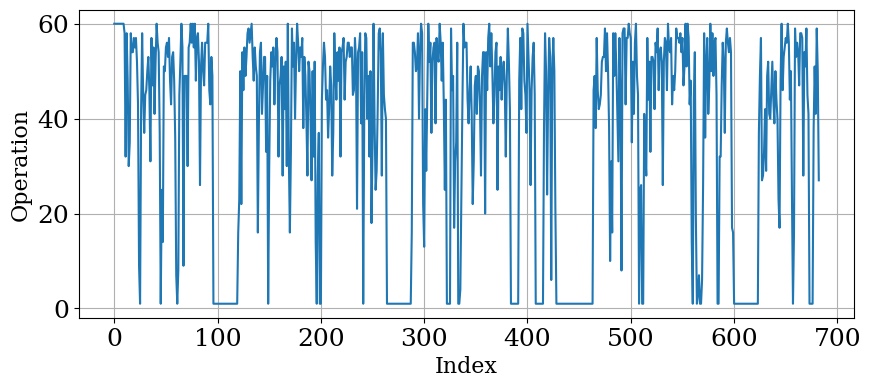

In [6]:
import matplotlib.pyplot as plt

# Reset index
data = data.reset_index(drop=True)

# Plot the 'Operation' column by index
plt.figure(figsize=(10, 4))
plt.plot(data['Operation'].values)
plt.xlabel('Index')
plt.ylabel('Operation')
plt.grid(True)

# Save the plot as SVG
plt.savefig('ts_gh2.svg', format='svg')

# Show the plot
plt.show()

# prepare to store results

In [7]:
# Initialize a DataFrame to store results
def initialize_results():
    columns = ['Model_Name', 'MAE', 'MAPE','Cost']
    return pd.DataFrame(columns=columns)

# Function to add new results to the DataFrame
def update_results(results_df, model_name, mae, mape,Cost):
    new_result = {'Model_Name': model_name, 'MAE': mae, 'MAPE': mape , 'Cost': Cost}
    results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
    return results_df
# Example usage
if __name__ == "__main__":
    # Initialize results DataFrame
    main_results = initialize_results()

# MODEL 0 BASE SARIMA WITHOUT DECOMPOSITION

In [8]:
start_time=time.time()

In [9]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(data['Operation'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result

C:\Users\ar600780\AppData\Local\Temp\ipykernel_14632\3746776136.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(data['Operation'], regression='c')


{'KPSS Statistic': 0.1786824511629263,
 'p-value': 0.1,
 'Lags Used': 15,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [10]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(data['Operation'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(data['Operation'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[None, None, None]

In [11]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

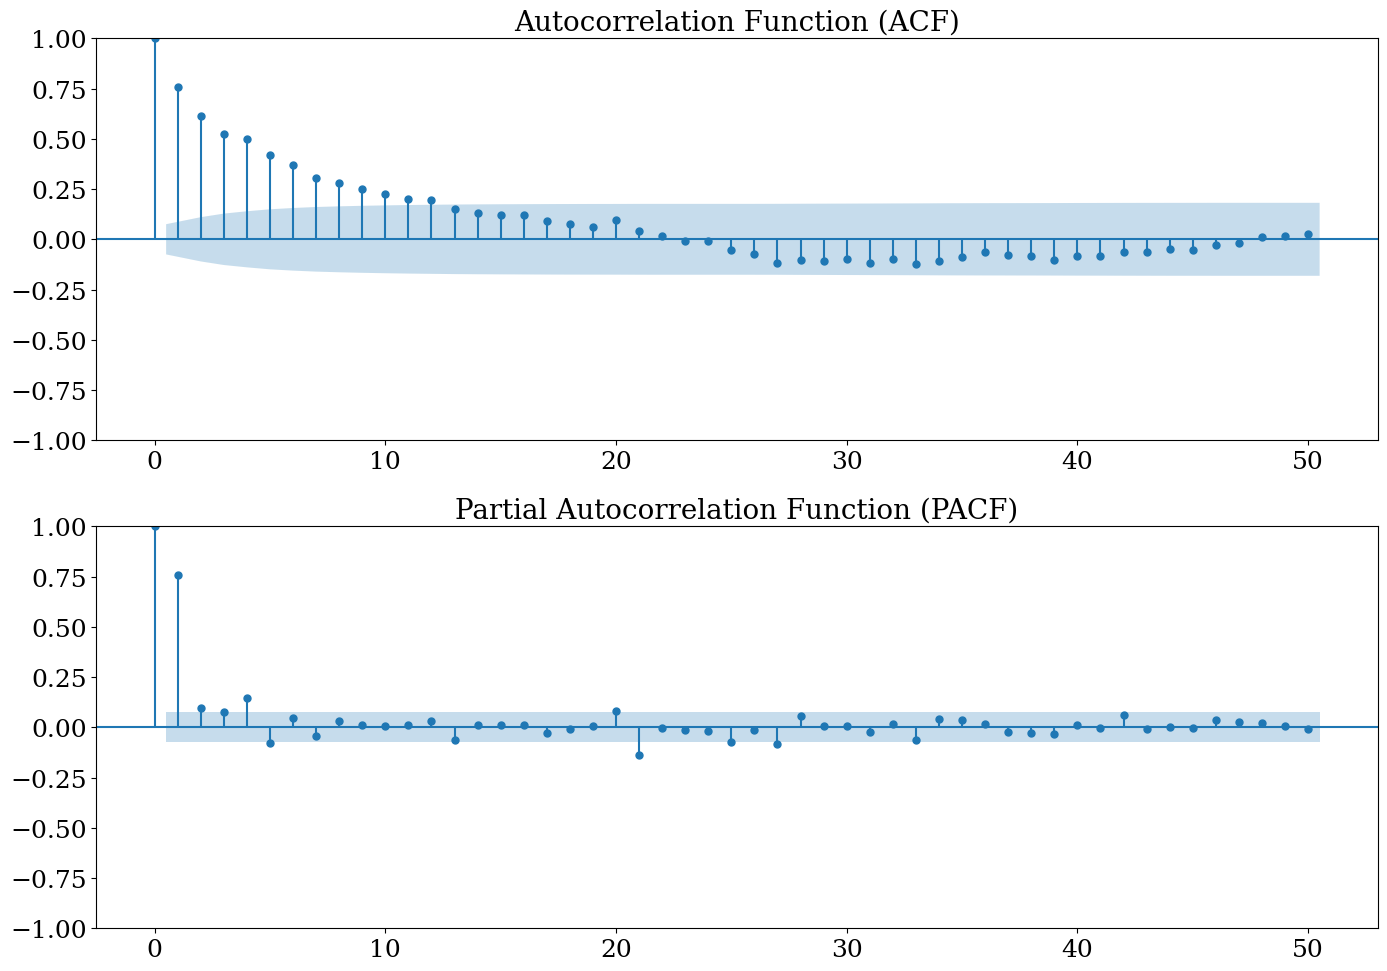

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(train_data['Operation'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(train_data['Operation'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file

plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:              Operation   No. Observations:                  679
Model:               SARIMAX(4, 0, 0)   Log Likelihood               -2774.460
Date:                Tue, 22 Apr 2025   AIC                           5558.921
Time:                        23:22:14   BIC                           5581.524
Sample:                             0   HQIC                          5567.671
                                - 679                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7120      0.034     20.703      0.000       0.645       0.779
ar.L2          0.0580      0.043      1.356      0.175      -0.026       0.142
ar.L3         -0.0039      0.047     -0.084      0.9

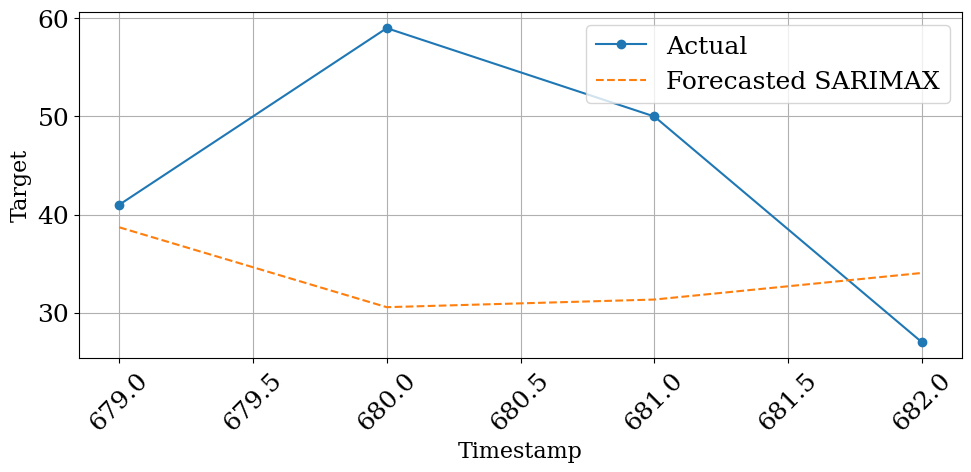

MAE: 14.11, MAPE: 0.29


In [13]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Ensure data is sorted
train_data = train_data.sort_index()
test_data = test_data.sort_index()

# Fit SARIMAX model with combined Fourier terms
model = SARIMAX(train_data['Operation'], 
                order=(4, 0, 0),  # AR(4) with no differencing
                seasonal_order=(0, 0, 0, 8)
                )  
sarimax_results = model.fit(disp=False)
print(sarimax_results.summary())
# Forecast using combined Fourier terms
sarimax_forecast = sarimax_results.get_forecast(steps=len(test_data)).predicted_mean


# Evaluation metrics
sarimax_mae = mean_absolute_error(test_data['Operation'], sarimax_forecast)
sarimax_mape = mean_absolute_percentage_error(test_data['Operation'], sarimax_forecast)


# Plot results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Operation'], label='Actual', marker='o')
plt.plot(test_data.index, sarimax_forecast, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print evaluation metrics
print(f"MAE: {sarimax_mae:.2f}, MAPE: {sarimax_mape:.2f}")
mae=sarimax_mae
mape=sarimax_mape 


In [14]:
end_time=time.time()

In [15]:
Cost=end_time-start_time

In [16]:
main_results = update_results(main_results, 'BASE SARIMA WITHOUT DECOMPOSITION', mae, mape,Cost)

In [17]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295


In [18]:
data

,DateTime,Operation
0,2024-08-14 00:00:00,60
1,2024-08-14 01:00:00,60
2,2024-08-14 02:00:00,60
3,2024-08-14 03:00:00,60
4,2024-08-14 04:00:00,60
...,...,...
678,2024-09-11 06:00:00,51
679,2024-09-11 07:00:00,41
680,2024-09-11 08:00:00,59
681,2024-09-11 09:00:00,50


In [19]:
# Define the number of test samples
test_size = 4

# Divide each DataFrame into train and test sets
data_master_train = data.iloc[:-test_size]
data_master_test = data.iloc[-test_size:]

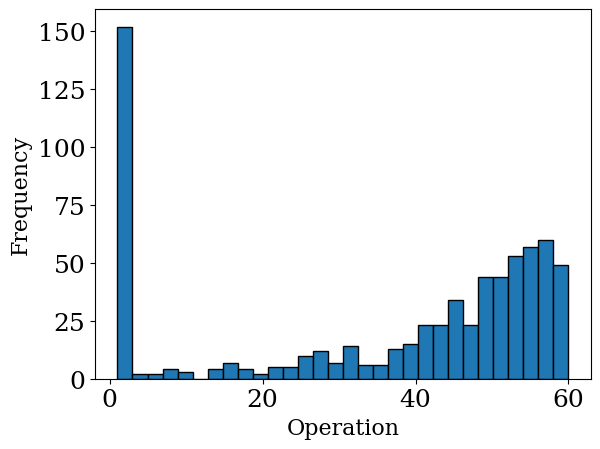

Skewness: -0.7110759282138528
Kurtosis: -1.1186466186033963


In [20]:
import matplotlib.pyplot as plt

# Plot the histogram for the 'Operation' column
plt.hist(data['Operation'], bins=30, edgecolor='black')
plt.xlabel('Operation')
plt.ylabel('Frequency')


# Save the figure as an SVG file
plt.savefig("hist_gh2.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()

# Calculate skewness and kurtosis
skewness = data['Operation'].skew()
kurtosis = data['Operation'].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)


## PART I DECOMPOSITION

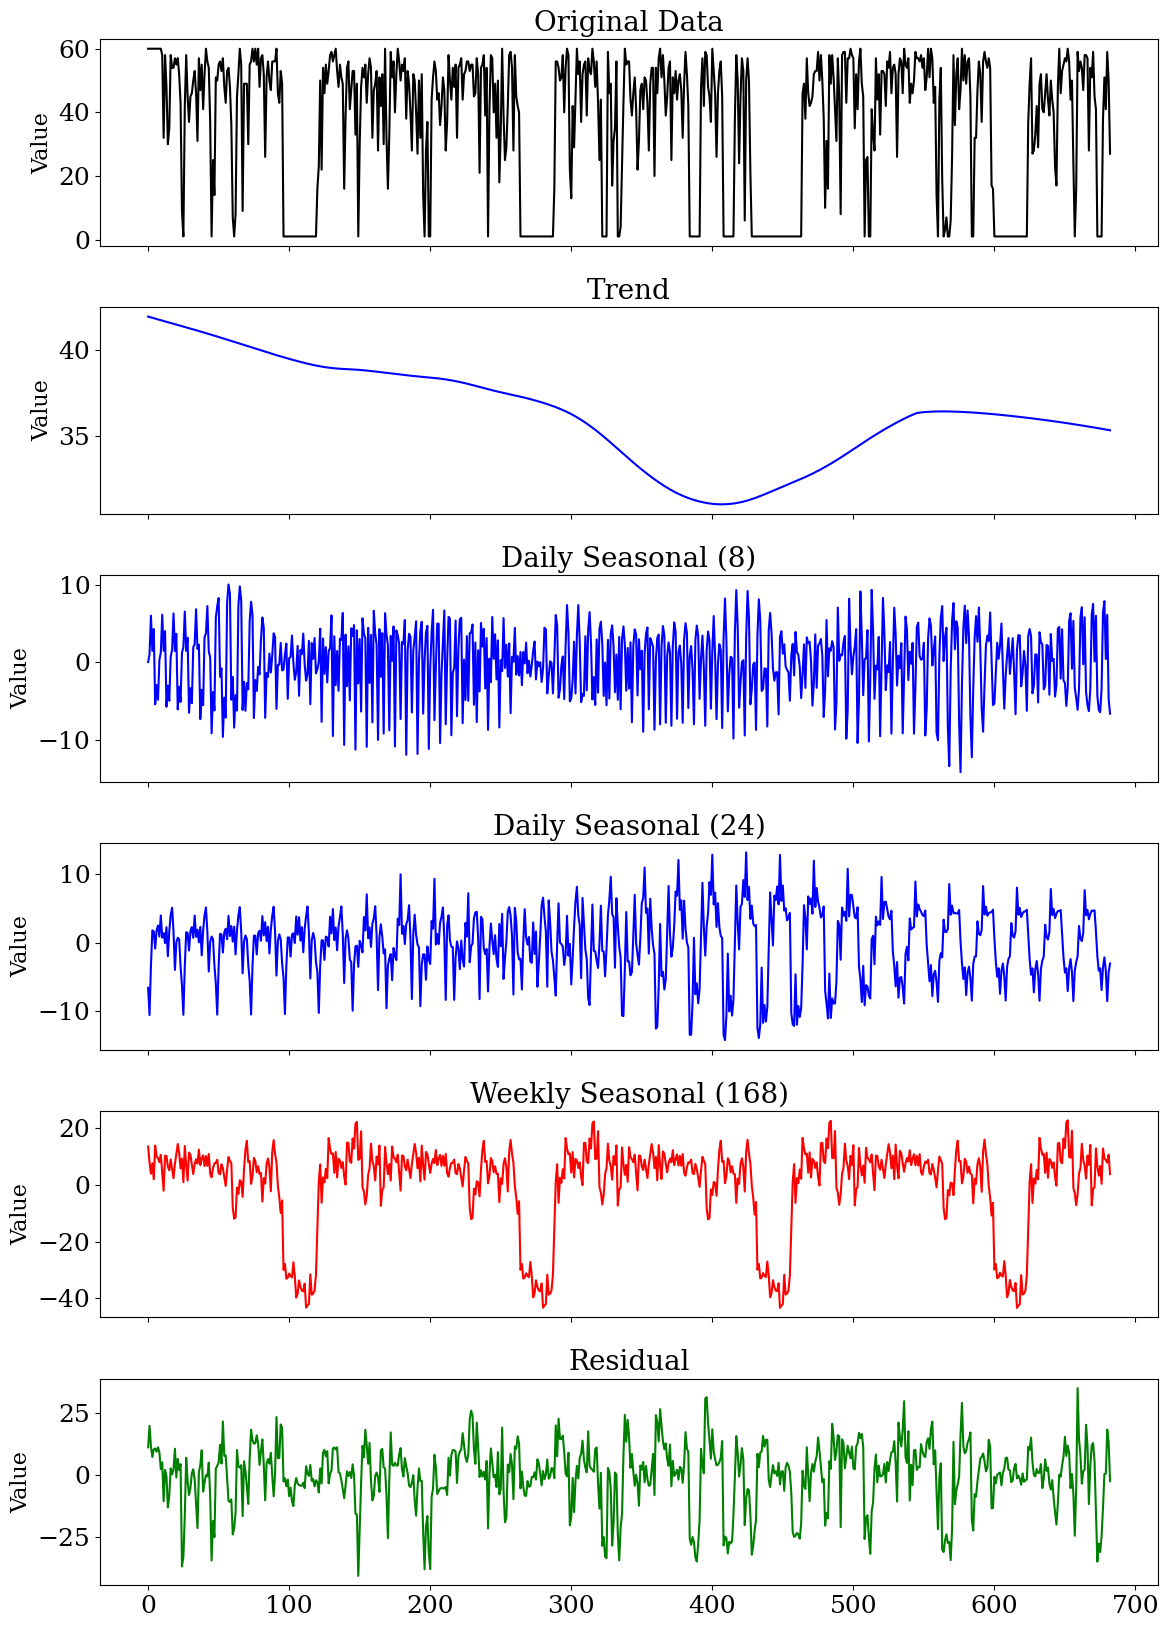

In [21]:
import pandas as pd
from statsmodels.tsa.seasonal import MSTL
import matplotlib.pyplot as plt

# Ensure the data is sorted by time
data = data.sort_index()

# MSTL decomposition
stl_kwargs = {"seasonal_deg": 0}
model = MSTL(data['Operation'], periods=(8, 24, 168), stl_kwargs=stl_kwargs)
res = model.fit()

# Extracting the seasonal components
seasonal_8=res.seasonal.iloc[:, 0]
seasonal_24 = res.seasonal.iloc[:, 1]  # Daily seasonal component
seasonal_168 = res.seasonal.iloc[:, 2]  # Weekly seasonal component
trend = res.trend
residual = res.resid

# Plotting
fig, axes = plt.subplots(6, 1, figsize=(12, 18), sharex=True)

data['Operation'].plot(ax=axes[0], color='black', title='Original Data')
axes[0].set_ylabel('Value')


trend.plot(ax=axes[1], color='blue', title='Trend')
axes[1].set_ylabel('Value')


seasonal_8.plot(ax=axes[2], color='blue', title='Daily Seasonal (8)')
axes[2].set_ylabel('Value')


seasonal_24.plot(ax=axes[3], color='blue', title='Daily Seasonal (24)')
axes[3].set_ylabel('Value')


seasonal_168.plot(ax=axes[4], color='red', title='Weekly Seasonal (168)')
axes[4].set_ylabel('Value')


residual.plot(ax=axes[5], color='green', title='Residual')
axes[5].set_ylabel('Value')

# Save the figure as an SVG file
plt.savefig("d_gh2.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [22]:
# Create DataFrames for each component
trend_df = pd.DataFrame({'Trend': trend})
seasonal_8_df = pd.DataFrame( {'Seasonal_8': seasonal_8})
seasonal_24_df = pd.DataFrame({ 'Seasonal_24': seasonal_24})
seasonal_168_df = pd.DataFrame({ 'Seasonal_168': seasonal_168})
residual_df = pd.DataFrame({ 'Operation': residual})

In [23]:
# Define the number of test samples
test_size = 4

# Divide each DataFrame into train and test sets
trend_train = trend_df.iloc[:-test_size]
trend_test = trend_df.iloc[-test_size:]

seasonal_8_train = seasonal_8_df.iloc[:-test_size]
seasonal_8_test = seasonal_8_df.iloc[-test_size:]

seasonal_24_train = seasonal_24_df.iloc[:-test_size]
seasonal_24_test = seasonal_24_df.iloc[-test_size:]

seasonal_168_train = seasonal_168_df.iloc[:-test_size]
seasonal_168_test = seasonal_168_df.iloc[-test_size:]

In [24]:
import pandas as pd

# Create the new DataFrame with a single column 'total' that is the sum of the specified columns
decompose_df = pd.DataFrame()
decompose_df['total'] = (
    trend_train['Trend'] +
    seasonal_8_train['Seasonal_8'] +
    seasonal_24_train['Seasonal_24'] +
    seasonal_168_train['Seasonal_168']
)


In [25]:
decompose_df

,total
0,48.915614
1,40.324988
2,48.565790
3,52.791812
4,49.761985
...,...
674,28.507008
675,31.888084
676,25.496637
677,51.115758


In [26]:
reference=data['Operation'].iloc[-test_size:]

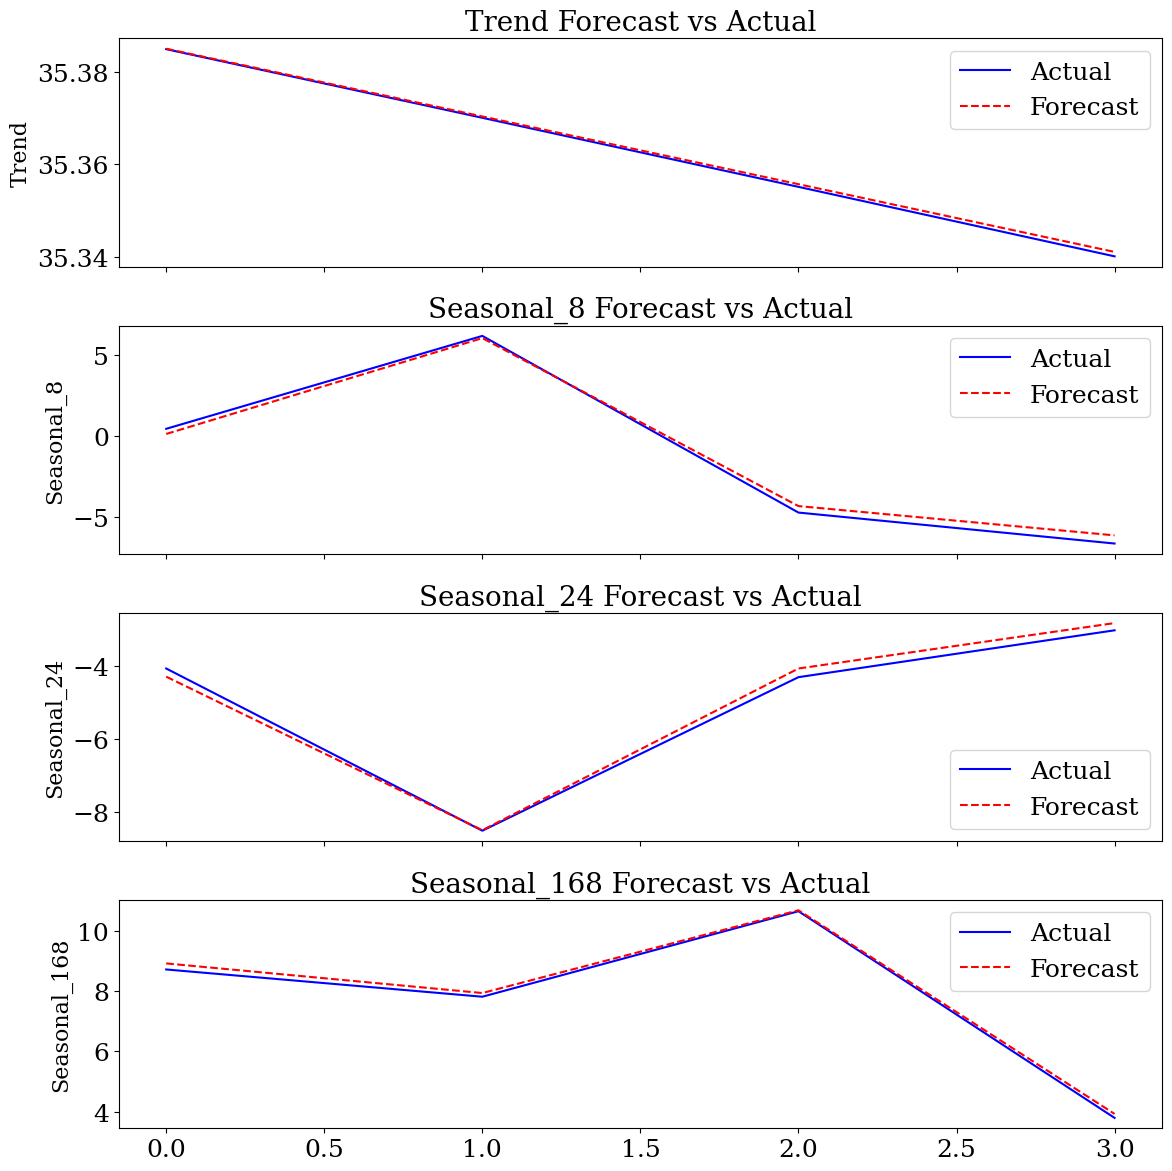

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Initialize dictionaries to store results
mae_results = {}
mape_results = {}


# Define the ETS model (additive trend)
trend_model = ExponentialSmoothing(
    trend_train['Trend'], 
    trend='add',  # Use 'mul' for multiplicative trend if appropriate
    seasonal=None,  # No seasonality for pure trend modeling
    damped_trend=False  # Set to True if a damped trend is preferred
)

# Fit the model
fitted_trend_model = trend_model.fit()

# Forecast the next 20 data points
trend_forecast = np.array(fitted_trend_model.forecast(len(trend_test)))


# Calculate error metrics
mae_results['Trend'] = mean_absolute_error(trend_test['Trend'], trend_forecast)
mape_results['Trend'] = mean_absolute_percentage_error(trend_test['Trend'], trend_forecast)


# Forecast Seasonal (8) by repeating the last period's values
seasonal_8_forecast = np.tile(
    seasonal_8_train['Seasonal_8'][-8:].values,
    len(seasonal_8_test) // 8 + 1
)[:len(seasonal_8_test)]
mae_results['Seasonal_8'] = mean_absolute_error(seasonal_8_test['Seasonal_8'], seasonal_8_forecast)
mape_results['Seasonal_8'] = mean_absolute_percentage_error(seasonal_8_test['Seasonal_8'], seasonal_8_forecast)

# Forecast Seasonal (24) by repeating the last period's values
seasonal_24_forecast = np.tile(
    seasonal_24_train['Seasonal_24'][-24:].values,
    len(seasonal_24_test) // 24 + 1
)[:len(seasonal_24_test)]
mae_results['Seasonal_24'] = mean_absolute_error(seasonal_24_test['Seasonal_24'], seasonal_24_forecast)
mape_results['Seasonal_24'] = mean_absolute_percentage_error(seasonal_24_test['Seasonal_24'], seasonal_24_forecast)

# Forecast Seasonal (168) similarly
seasonal_168_forecast = np.tile(
    seasonal_168_train['Seasonal_168'][-168:].values,
    len(seasonal_168_test) // 168 + 1
)[:len(seasonal_168_test)]
mae_results['Seasonal_168'] = mean_absolute_error(seasonal_168_test['Seasonal_168'], seasonal_168_forecast)
mape_results['Seasonal_168'] = mean_absolute_percentage_error(seasonal_168_test['Seasonal_168'], seasonal_168_forecast)

# Plotting
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
components = ['Trend', 'Seasonal_8','Seasonal_24', 'Seasonal_168']
forecasts = [trend_forecast, seasonal_8_forecast, seasonal_24_forecast, seasonal_168_forecast]
test_data = [trend_test['Trend'],seasonal_8_test['Seasonal_8'], seasonal_24_test['Seasonal_24'], seasonal_168_test['Seasonal_168']]

for i, component in enumerate(components):
    axes[i].plot(test_data[i].values, label="Actual", color='blue')
    axes[i].plot(forecasts[i], label="Forecast", color='red', linestyle='dashed')
    axes[i].set_title(f'{component} Forecast vs Actual')
    axes[i].set_ylabel(component)
    axes[i].legend()

plt.tight_layout()
plt.show()



In [28]:
summed_up_array = np.sum(forecasts, axis=0)

In [29]:
import pandas as pd

# Assuming 'reference_df' is the reference DataFrame with the desired index
# and 'summed_up' is the array with values

summed_up = pd.DataFrame({
    'Index': reference.index,  # Use the index from the reference DataFrame
    'sum': summed_up_array  # Use the values from the array
})

# Set the index to match the reference DataFrame
summed_up.set_index('Index', inplace=True)

# Display the DataFrame
print(summed_up)

             sum
Index           
679    40.115999
680    40.819650
681    37.624510
682    30.303744


In [30]:
reference

679    41
680    59
681    50
682    27
Name: Operation, dtype: int64

In [31]:
file_path = 'summed_up.xlsx'
summed_up.to_excel(file_path, index=False)  # index=False to exclude the index column

In [32]:
file_path = 'reference.xlsx'
reference.to_excel(file_path, index=False)  # index=False to exclude the index column

## PART II FEATURE EXTRACTION

In [33]:
window_length = 24
window_size = 24
time_delay = 8
dimension = 3
stride = 1

In [34]:
df=residual_df

### STATISTICAL FEATURE EXTRACTION by TSFRESH

In [35]:
from tsfresh.feature_extraction import extract_features
from tsfresh.utilities.dataframe_functions import roll_time_series

In [36]:
start_time = time.time()

# Ensure tsfresh is installed
# !pip install tsfresh

# Add an index column to represent time
df['id'] = 1  # All data belongs to one time series
df['time'] = range(len(df))

# Rolling window to create overlapping segments
rolled_df = roll_time_series(df, column_id='id', column_sort='time', max_timeshift=window_size-1)

# Extract features using tsfresh
extracted_features = extract_features(
    rolled_df,
    column_id='id',
    column_sort='time',
    column_value='Operation',
    disable_progressbar=False
)


Feature Extraction: 100%|██████████| 30/30 [00:54<00:00,  1.80s/it]


In [37]:
extracted_features=extracted_features.reset_index(drop=True)

In [38]:
data = extracted_features.iloc[window_length-1:].reset_index(drop=True)

In [39]:
data

,Operation__variance_larger_than_standard_deviation,Operation__has_duplicate_max,Operation__has_duplicate_min,Operation__has_duplicate,Operation__sum_values,Operation__abs_energy,Operation__mean_abs_change,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,...,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_3__tau_1,Operation__permutation_entropy__dimension_4__tau_1,Operation__permutation_entropy__dimension_5__tau_1,Operation__permutation_entropy__dimension_6__tau_1,Operation__permutation_entropy__dimension_7__tau_1,Operation__query_similarity_count__query_None__threshold_0.0,Operation__mean_n_absolute_max__number_of_maxima_7
0,1.0,0.0,0.0,0.0,104.090251,1777.781655,5.937577,-0.292738,-0.141319,4.713433,...,0.937156,1.377820,2.245035,1.668161,2.623522,2.995732,2.944439,2.890372,NaN,12.493484
1,1.0,0.0,0.0,0.0,56.375349,2996.712722,7.345895,-2.448066,-0.744117,3.514297,...,0.937156,1.412745,2.351673,1.656676,2.623522,2.995732,2.944439,2.890372,NaN,16.142931
2,1.0,0.0,0.0,0.0,3.945063,3682.514623,7.156088,-1.921282,0.184120,2.540164,...,1.031767,1.605207,2.458311,1.606466,2.648438,2.926418,2.944439,2.890372,NaN,18.011540
3,1.0,0.0,0.0,0.0,-23.732091,3815.606683,7.690275,-1.019614,0.306421,2.253440,...,1.031767,1.524707,2.204785,1.641230,2.648438,2.926418,2.944439,2.890372,NaN,18.698502
4,1.0,0.0,0.0,0.0,-24.048696,3811.142620,8.564392,-0.145497,0.517007,2.253440,...,1.031767,1.263626,2.351673,1.641230,2.648438,2.926418,2.944439,2.890372,NaN,18.698502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,1.0,0.0,0.0,0.0,-70.624516,7115.503999,12.672339,0.000283,0.487154,0.409519,...,0.937156,1.377820,2.458311,1.620593,2.466577,2.787788,2.944439,2.890372,NaN,28.121152
656,1.0,0.0,0.0,0.0,-70.486881,7115.634776,12.334290,0.349735,0.385660,0.478337,...,1.031767,1.410514,2.458311,1.606466,2.359466,2.787788,2.944439,2.890372,NaN,28.121152
657,1.0,0.0,0.0,0.0,-44.806519,7389.910443,12.369009,1.848621,-0.036407,1.024297,...,1.178655,1.410514,2.311423,1.526775,2.306336,2.718473,2.944439,2.890372,NaN,28.121152
658,1.0,0.0,0.0,0.0,-7.423011,6967.763716,11.755810,0.788919,-1.023037,1.803817,...,1.072017,1.517152,2.311423,1.567236,2.306336,2.649159,2.944439,2.890372,NaN,27.241502


In [40]:
residual_df

,Operation,id,time
0,11.084386,1,0
1,19.675012,1,1
2,11.434210,1,2
3,7.208188,1,3
4,10.238015,1,4
...,...,...,...
678,0.412770,1,678
679,0.543904,1,679
680,18.180364,1,680
681,13.045591,1,681


In [41]:
df_ref = df.iloc[window_length-1:].reset_index(drop=True)

In [42]:
# Identify columns with inf, -inf, or NaN values
cols_with_invalid_values = data.columns[data.isin([np.inf, -np.inf]).any() | data.isna().any()]

# Replace inf and -inf with NaN first
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column mean
data[cols_with_invalid_values] = data[cols_with_invalid_values].apply(lambda col: col.fillna(col.mean()), axis=0)


In [43]:
df_ref = df_ref.drop(index=0).reset_index(drop=True)

In [44]:
regression_target_series = df_ref['Operation']

In [45]:
# Combine features and target into a single dataset for regression analysis
regression_dataset = data.copy()

In [46]:
regression_dataset['Target'] = regression_target_series

In [47]:
df1=regression_dataset

In [48]:
df1 = df1.drop(index=df1.index[-1]).reset_index(drop=True)

In [49]:
df1 = df1.dropna(axis=1, how='all').loc[:, ~(df1 == np.inf).all()]

In [50]:
# Dropping columns with low variance from df1
if 'df1' in locals():
    # Calculate variance of each column
    variance = df1.var()
    
    # Threshold for low variance (can be adjusted)
    low_variance_threshold = 0.01  # Example: close to zero variance
    
    # Identify columns with variance below the threshold
    low_variance_columns = variance[variance < low_variance_threshold].index
    
    # Drop low variance columns
    df1 = df1.drop(columns=low_variance_columns)

In [51]:
df1

,Operation__sum_values,Operation__abs_energy,Operation__mean_abs_change,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,Operation__mean,Operation__standard_deviation,Operation__variation_coefficient,Operation__variance,...,Operation__count_above__t_0,Operation__count_below__t_0,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Operation__mean_n_absolute_max__number_of_maxima_7,Target
0,104.090251,1777.781655,5.937577,-0.292738,-0.141319,4.713433,4.337094,7.433966,1.714043,55.263853,...,0.791667,0.208333,0.429323,0.535961,0.937156,1.377820,2.245035,2.623522,12.493484,-36.630516
1,56.375349,2996.712722,7.345895,-2.448066,-0.744117,3.514297,2.348973,10.924530,4.650769,119.345356,...,0.750000,0.250000,0.429323,0.687092,0.937156,1.412745,2.351673,2.623522,16.142931,-32.755274
2,3.945063,3682.514623,7.156088,-1.921282,0.184120,2.540164,0.164378,12.385923,75.350410,153.411089,...,0.708333,0.291667,0.271189,0.687092,1.031767,1.605207,2.458311,2.648438,18.011540,-16.242944
3,-23.732091,3815.606683,7.690275,-1.019614,0.306421,2.253440,-0.988837,12.570036,-12.711938,158.005813,...,0.666667,0.333333,0.271189,0.687092,1.031767,1.524707,2.204785,2.648438,18.698502,6.891582
4,-24.048696,3811.142620,8.564392,-0.145497,0.517007,2.253440,-1.002029,12.561590,-12.536154,157.793547,...,0.666667,0.333333,0.271189,0.535961,1.031767,1.263626,2.351673,2.648438,18.698502,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,-76.312552,7143.162051,12.331165,-0.340891,0.129531,-1.534871,-3.179690,16.956454,-5.332739,287.521326,...,0.500000,0.500000,0.540204,0.790268,0.937156,1.377820,2.351673,2.491494,28.121152,0.412770
655,-70.624516,7115.503999,12.672339,0.000283,0.487154,0.409519,-2.942688,16.965256,-5.765224,287.819920,...,0.541667,0.458333,0.540204,0.687092,0.937156,1.377820,2.458311,2.466577,28.121152,0.543904
656,-70.486881,7115.634776,12.334290,0.349735,0.385660,0.478337,-2.936953,16.966411,-5.776874,287.859087,...,0.541667,0.458333,0.429323,0.790268,1.031767,1.410514,2.458311,2.359466,28.121152,18.180364
657,-44.806519,7389.910443,12.369009,1.848621,-0.036407,1.024297,-1.866938,17.447850,-9.345703,304.427477,...,0.583333,0.416667,0.429323,0.830518,1.178655,1.410514,2.311423,2.306336,28.121152,13.045591


In [52]:
from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

In [53]:
# Assume the last column is the target variable (modify if needed)
target_column = "Target"  # Change if your target column has a different name
X = df1.drop(columns=[target_column])  # Extract feature columns
y = df1[target_column]  # Define the target variable

# Initialize SmartCorrelatedSelection for regression
tr = SmartCorrelatedSelection(
    variables=None,  # Apply to all numeric features
    method="pearson",  # Pearson correlation method
    threshold=0.9,  # Correlation threshold
    missing_values="raise",  # Raise error if missing values exist
    selection_method="model_performance",  # Use model performance to select features
    estimator=RandomForestRegressor(random_state=1, n_estimators=100),  # RandomForest for regression
    scoring="r2",  # Use R² as the evaluation metric
    cv=3  # 3-fold cross-validation
)

# Fit and transform the dataset to select best features
X_selected = tr.fit_transform(X, y)

# Reconstruct df2 with selected features and target variable
df1 = pd.concat([X_selected, y], axis=1)

In [54]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
features = df1.drop(columns=["Target"])
target = df1["Target"]

# Apply scaling only to features
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)

# Recombine scaled features with the original Target
df1_scaled = pd.concat([features_scaled, target], axis=1)

In [55]:
end_time = time.time()
statistical_ext=start_time-end_time

In [56]:
file_path = 'statistical_data.xlsx'
df1_scaled.to_excel(file_path, index=False)  # index=False to exclude the index column

### TOPOLOGICAL FEATURE EXTRACTION

In [57]:
import pandas as pd
import numpy as np
from gtda.diagrams import (
    Scaler, PersistenceEntropy, Amplitude, BettiCurve, 
    PersistenceLandscape, Silhouette, HeatKernel
)
import gtda.time_series as ts
import gtda.diagrams as diag
from gtda.time_series import TakensEmbedding
from gtda.time_series import SlidingWindow
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from gtda.pipeline import Pipeline
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_point_cloud

In [58]:
start_time = time.time()

In [59]:
X=df['Operation']

In [60]:
import numpy as np
import pandas as pd
from gtda.time_series import SlidingWindow, TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Scaler

# Load your data (replace 'df' with your actual DataFrame)
X = df['Operation'].to_numpy()

# Sliding Window
SW = SlidingWindow(size=window_size, stride=stride)
X_sw = SW.fit_transform(X)

# Debugging shape
print(f"Sliding Window Output Shape: {X_sw.shape}")

# Takens Embedding
TE = TakensEmbedding(time_delay=time_delay, dimension=dimension)
X_te = TE.fit_transform(X_sw)

# Debugging shape
print(f"Takens Embedding Output Shape: {X_te.shape}")

# Vietoris-Rips Persistence
VR = VietorisRipsPersistence(homology_dimensions=[0, 1])
diagrams = VR.fit_transform(X_te)

# Debugging number of diagrams
print(f"Number of Persistence Diagrams: {len(diagrams)}")

# Scaling Persistence Diagrams
scaler = Scaler()
scaled_diagrams = scaler.fit_transform(diagrams)

# Debugging scaled diagrams shape
print(f"Scaled Diagrams Shape: {scaled_diagrams.shape}")


Sliding Window Output Shape: (660, 24)
Takens Embedding Output Shape: (660, 8, 3)


D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Number of Persistence Diagrams: 660
Scaled Diagrams Shape: (660, 9, 3)


D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [61]:
# Initialize feature extractors
persistence_entropy = PersistenceEntropy()
amplitude_bottleneck = Amplitude(metric='bottleneck')
amplitude_wasserstein = Amplitude(metric='wasserstein')
amplitude_landscape = Amplitude(metric='landscape')
betti_curve = BettiCurve()
persistence_landscape = PersistenceLandscape()
silhouette = Silhouette()
heat_kernel = HeatKernel(sigma=0.1, n_bins=100, n_jobs=-1)

In [62]:
# Extract features
entropy_features = persistence_entropy.fit_transform(scaled_diagrams)
amplitude_bottleneck_features = amplitude_bottleneck.fit_transform(scaled_diagrams)
amplitude_wasserstein_features = amplitude_wasserstein.fit_transform(scaled_diagrams)
amplitude_landscape_features = amplitude_landscape.fit_transform(scaled_diagrams)
betti_features = betti_curve.fit_transform(scaled_diagrams)
landscape_features = persistence_landscape.fit_transform(scaled_diagrams)
silhouette_features = silhouette.fit_transform(scaled_diagrams)
heat_kernel_features = heat_kernel.fit_transform(scaled_diagrams)

D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force

In [63]:
betti_features.shape

(660, 2, 100)

In [64]:
l1_h0 = []
l2_h0 = []
l1_h1 = []
l2_h1 = []

for i in range(betti_features.shape[0]):
    h0_curve = betti_features[i, 0, :]
    h1_curve = betti_features[i, 1, :]

    l1_h0.append(np.sum(np.abs(h0_curve)))
    l2_h0.append(np.sqrt(np.sum(h0_curve**2)))

    l1_h1.append(np.sum(np.abs(h1_curve)))
    l2_h1.append(np.sqrt(np.sum(h1_curve**2)))

# Create DataFrame
betti_df = pd.DataFrame({
    'betti_L1_H0': l1_h0,
    'betti_L2_H0': l2_h0,
    'betti_L1_H1': l1_h1,
    'betti_L2_H1': l2_h1
})

# Show result
betti_df


,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1
0,92,23.323808,0,0.0
1,154,26.038433,0,0.0
2,146,25.768197,0,0.0
3,140,27.892651,0,0.0
4,172,29.799329,0,0.0
...,...,...,...,...
655,257,39.761791,0,0.0
656,246,38.183766,0,0.0
657,270,39.673669,0,0.0
658,280,40.224371,0,0.0


In [65]:
l1_h0_ls = []
l2_h0_ls = []
l1_h1_ls = []
l2_h1_ls = []

for i in range(landscape_features.shape[0]):
    h0_landscape = landscape_features[i, 0, :]
    h1_landscape = landscape_features[i, 1, :]

    l1_h0_ls.append(np.sum(np.abs(h0_landscape)))
    l2_h0_ls.append(np.sqrt(np.sum(h0_landscape**2)))

    l1_h1_ls.append(np.sum(np.abs(h1_landscape)))
    l2_h1_ls.append(np.sqrt(np.sum(h1_landscape**2)))

# Create DataFrame
landscape_df = pd.DataFrame({
    'landscape_features_L1_H0_LS': l1_h0_ls,
    'landscape_features_L2_H0_LS': l2_h0_ls,
    'landscape_features_L1_H1_LS': l1_h1_ls,
    'landscape_features_L2_H1_LS': l2_h1_ls
})

# Show result
landscape_df


,landscape_features_L1_H0_LS,landscape_features_L2_H0_LS,landscape_features_L1_H1_LS,landscape_features_L2_H1_LS
0,1.513497,0.420032,0.0,0.0
1,24.462327,3.386027,0.0,0.0
2,20.644626,2.981912,0.0,0.0
3,5.458578,1.099405,0.0,0.0
4,10.916436,1.848746,0.0,0.0
...,...,...,...,...
655,13.395804,2.155462,0.0,0.0
656,13.395804,2.155462,0.0,0.0
657,14.054394,2.234423,0.0,0.0
658,14.241323,2.256748,0.0,0.0


In [66]:
l1_h0_si = []
l2_h0_si = []
l1_h1_si = []
l2_h1_si = []

for i in range(silhouette_features.shape[0]):
    h0_silhouette = silhouette_features[i, 0, :]
    h1_silhouette = silhouette_features[i, 1, :]

    l1_h0_si.append(np.sum(np.abs(h0_silhouette)))
    l2_h0_si.append(np.sqrt(np.sum(h0_silhouette**2)))

    l1_h1_si.append(np.sum(np.abs(h1_silhouette)))
    l2_h1_si.append(np.sqrt(np.sum(h1_silhouette**2)))

# Create DataFrame
silhouette_df = pd.DataFrame({
    'silhouette_features_L1_H0_SI': l1_h0_si,
    'silhouette_features_L2_H0_SI': l2_h0_si,
    'silhouette_features_L1_H1_SI': l1_h1_si,
    'silhouette_features_L2_H1_SI': l2_h1_si
})

# Show result
silhouette_df.head()


,silhouette_features_L1_H0_SI,silhouette_features_L2_H0_SI,silhouette_features_L1_H1_SI,silhouette_features_L2_H1_SI
0,1.001876,0.286144,0.0,0.0
1,11.831305,1.592521,0.0,0.0
2,9.727442,1.361798,0.0,0.0
3,3.047797,0.604552,0.0,0.0
4,5.385877,0.922545,0.0,0.0


In [67]:
# Flatten entropy features
entropy_flattened = entropy_features.reshape(entropy_features.shape[0], -1)
entropy_df = pd.DataFrame(entropy_flattened, columns=[f"entropy_{i}" for i in range(entropy_flattened.shape[1])])

In [68]:
entropy_df

,entropy_0,entropy_1
0,2.752234,-1.0
1,2.371039,-1.0
2,2.410209,-1.0
3,2.691061,-1.0
4,2.633835,-1.0
...,...,...
655,2.771606,-1.0
656,2.745287,-1.0
657,2.734335,-1.0
658,2.725553,-1.0


In [69]:
# Flatten amplitude bottleneck features
amplitude_bottleneck_flattened = amplitude_bottleneck_features.reshape(amplitude_bottleneck_features.shape[0], -1)
amplitude_bottleneck_df = pd.DataFrame(amplitude_bottleneck_flattened, columns=[f"amplitude_bottleneck_{i}" for i in range(amplitude_bottleneck_flattened.shape[1])])
amplitude_bottleneck_df 

,amplitude_bottleneck_0,amplitude_bottleneck_1
0,0.174992,0.0
1,0.702997,0.0
2,0.645805,0.0
3,0.332197,0.0
4,0.469637,0.0
...,...,...
655,0.520238,0.0
656,0.520238,0.0
657,0.532903,0.0
658,0.536455,0.0


In [70]:
# Flatten amplitude wasserstein features
amplitude_wasserstein_flattened = amplitude_wasserstein_features.reshape(amplitude_wasserstein_features.shape[0], -1)
amplitude_wasserstein_df = pd.DataFrame(amplitude_wasserstein_flattened, columns=[f"amplitude_wasserstein_{i}" for i in range(amplitude_wasserstein_flattened.shape[1])])
amplitude_wasserstein_df


,amplitude_wasserstein_0,amplitude_wasserstein_1
0,0.353751,0.0
1,0.783087,0.0
2,0.728378,0.0
3,0.566809,0.0
4,0.720698,0.0
...,...,...
655,0.987328,0.0
656,0.959297,0.0
657,1.059080,0.0
658,1.103921,0.0


In [71]:
amplitude_landscape_flattened = amplitude_landscape_features.reshape(amplitude_landscape_features.shape[0], -1)
amplitude_landscape_df = pd.DataFrame(amplitude_landscape_flattened, columns=[f"amplitude_landscape_{i}" for i in range(amplitude_landscape_flattened.shape[1])])
amplitude_landscape_df 

,amplitude_landscape_0,amplitude_landscape_1
0,0.059701,0.0
1,0.481269,0.0
2,0.423831,0.0
3,0.156263,0.0
4,0.262769,0.0
...,...,...
655,0.306364,0.0
656,0.306364,0.0
657,0.317587,0.0
658,0.320760,0.0


In [72]:
heat_kernel_features.shape

(660, 2, 100, 100)

In [73]:
def compute_entropy(matrix):
    p = matrix.flatten()
    p = p[p > 0]  # Avoid log(0)
    p /= p.sum()  # Normalize to probability distribution
    return -np.sum(p * np.log(p))

def extract_heat_kernel_features(heat_kernel_features):
    feature_list = []

    for i in range(heat_kernel_features.shape[0]):  # for each sample
        features_sample = {}

        for dim, h_dim in enumerate(["H0", "H1"]):
            matrix = heat_kernel_features[i, dim, :, :]  # shape: (100, 100)

            # Global features
            features_sample[f"L1_{h_dim}"] = np.sum(np.abs(matrix))
            features_sample[f"L2_{h_dim}"] = np.sqrt(np.sum(matrix ** 2))

            # Per-column features
            for col in range(matrix.shape[1]):
                col_data = matrix[:, col]
                features_sample[f"Col{col}_L1_{h_dim}"] = np.sum(np.abs(col_data))
                features_sample[f"Col{col}_L2_{h_dim}"] = np.sqrt(np.sum(col_data ** 2))

        feature_list.append(features_sample)

    heat_kernel_df = pd.DataFrame(feature_list)
    return heat_kernel_df

# Usage
heat_kernel_df = extract_heat_kernel_features(heat_kernel_features)
heat_kernel_df.head()


,L1_H0,L2_H0,Col0_L1_H0,Col0_L2_H0,Col1_L1_H0,Col1_L2_H0,Col2_L1_H0,Col2_L2_H0,Col3_L1_H0,Col3_L2_H0,...,Col95_L1_H1,Col95_L2_H1,Col96_L1_H1,Col96_L2_H1,Col97_L1_H1,Col97_L2_H1,Col98_L1_H1,Col98_L2_H1,Col99_L1_H1,Col99_L2_H1
0,14780.739950,851.996935,1268.589474,284.834922,1218.329991,275.937312,1126.531241,256.049982,1008.878076,228.109502,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,16073.272180,784.559677,1320.588933,258.566537,1278.203424,251.667525,1189.365851,234.723309,1068.188481,209.994609,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,15991.950396,796.035382,1319.670733,262.794423,1276.877467,255.715700,1187.704520,238.401996,1066.472170,213.167947,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,17207.921636,766.832634,1359.770202,248.679958,1324.843626,243.104098,1239.545064,227.925182,1116.101930,204.960178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17426.365951,660.953043,1362.052098,214.005313,1328.115302,209.235764,1243.628981,196.224079,1120.318054,176.533461,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
# Combine all the DataFrames into a single DataFrame
combined_df = pd.concat([
    entropy_df,
    amplitude_bottleneck_df,
    amplitude_wasserstein_df,
    amplitude_landscape_df,
    betti_df,
    landscape_df,
    silhouette_df,
    heat_kernel_df
], axis=1)


In [75]:
def compute_carlsson_features(births, deaths, fn_max=5):
    lifetimes = deaths - births
    d_max = np.max(deaths) if len(deaths) > 0 else 0
    
    f1 = np.sum(births * lifetimes) if fn_max >= 1 else None
    f2 = np.sum((d_max - deaths) * lifetimes) if fn_max >= 2 else None
    f3 = np.sum((births ** 2) * (lifetimes ** 4)) if fn_max >= 3 else None
    f4 = np.sum(((d_max - deaths) ** 2) * (lifetimes ** 4)) if fn_max >= 4 else None
    f5 = np.max(lifetimes) if (fn_max >= 5 and len(lifetimes) > 0) else None

    return f1, f2, f3, f4, f5

features = {}
fn_max = 5  # You can adjust the number of Carlsson features

for dim in range(2):  # Loop over each homology dimension (0 and 1)
    filtered_diagrams = [diagram[diagram[:, 2] == dim] for diagram in scaled_diagrams]

    lifetimes = [diagram[:, 1] - diagram[:, 0] for diagram in filtered_diagrams]

    for i, lifetime in enumerate(lifetimes):
        sample_key = f'sample_{i + 1}'
        if sample_key not in features:
            features[sample_key] = {}

        features[sample_key][f'dim_{dim}_num_features'] = len(lifetime)
        features[sample_key][f'dim_{dim}_sum_lifetimes'] = np.sum(lifetime)

        if len(lifetime) > 0:
            features[sample_key][f'dim_{dim}_max_lifetime'] = np.max(lifetime)
            features[sample_key][f'dim_{dim}_mean_lifetime'] = np.mean(lifetime)
            features[sample_key][f'dim_{dim}_median_lifetime'] = np.median(lifetime)
            features[sample_key][f'dim_{dim}_std_lifetime'] = np.std(lifetime)
            features[sample_key][f'dim_{dim}_variance_lifetime'] = np.var(lifetime)
            features[sample_key][f'dim_{dim}_min_lifetime'] = np.min(lifetime)

            birth_times = filtered_diagrams[i][:, 0]
            death_times = filtered_diagrams[i][:, 1]

            features[sample_key][f'dim_{dim}_sum_birth_times'] = np.sum(birth_times)
            features[sample_key][f'dim_{dim}_mean_birth_time'] = np.mean(birth_times)
            features[sample_key][f'dim_{dim}_sum_death_times'] = np.sum(death_times)
            features[sample_key][f'dim_{dim}_mean_death_time'] = np.mean(death_times)

            # Add Carlsson features:
            f1, f2, f3, f4, f5 = compute_carlsson_features(birth_times, death_times, fn_max=fn_max)
            if f1 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f1'] = f1
            if f2 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f2'] = f2
            if f3 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f3'] = f3
            if f4 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f4'] = f4
            if f5 is not None:
                features[sample_key][f'dim_{dim}_carlsson_f5'] = f5

        else:
            # Fill zeros if empty diagram
            for metric in ['max_lifetime', 'mean_lifetime', 'median_lifetime', 'std_lifetime', 'variance_lifetime', 'min_lifetime', 'sum_birth_times', 'mean_birth_time', 'sum_death_times', 'mean_death_time']:
                features[sample_key][f'dim_{dim}_{metric}'] = 0

            # Add Carlsson feature zeros if empty
            for j in range(1, fn_max + 1):
                features[sample_key][f'dim_{dim}_carlsson_f{j}'] = 0

# Convert the nested dictionary to a DataFrame
features_df = pd.DataFrame.from_dict(features, orient='index')
features_df.reset_index(inplace=True)
features_df.rename(columns={'index': 'sample'}, inplace=True)
features_df.drop(columns=['sample'], inplace=True)

In [76]:
features_df.columns

Index(['dim_0_num_features', 'dim_0_sum_lifetimes', 'dim_0_max_lifetime',
       'dim_0_mean_lifetime', 'dim_0_median_lifetime', 'dim_0_std_lifetime',
       'dim_0_variance_lifetime', 'dim_0_min_lifetime',
       'dim_0_sum_birth_times', 'dim_0_mean_birth_time',
       'dim_0_sum_death_times', 'dim_0_mean_death_time', 'dim_0_carlsson_f1',
       'dim_0_carlsson_f2', 'dim_0_carlsson_f3', 'dim_0_carlsson_f4',
       'dim_0_carlsson_f5', 'dim_1_num_features', 'dim_1_sum_lifetimes',
       'dim_1_max_lifetime', 'dim_1_mean_lifetime', 'dim_1_median_lifetime',
       'dim_1_std_lifetime', 'dim_1_variance_lifetime', 'dim_1_min_lifetime',
       'dim_1_sum_birth_times', 'dim_1_mean_birth_time',
       'dim_1_sum_death_times', 'dim_1_mean_death_time', 'dim_1_carlsson_f1',
       'dim_1_carlsson_f2', 'dim_1_carlsson_f3', 'dim_1_carlsson_f4',
       'dim_1_carlsson_f5'],
      dtype='object')

In [77]:
features_df

,dim_0_num_features,dim_0_sum_lifetimes,dim_0_max_lifetime,dim_0_mean_lifetime,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_variance_lifetime,dim_0_min_lifetime,dim_0_sum_birth_times,dim_0_mean_birth_time,...,dim_1_min_lifetime,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,dim_1_carlsson_f1,dim_1_carlsson_f2,dim_1_carlsson_f3,dim_1_carlsson_f4,dim_1_carlsson_f5
0,7,1.806457,0.349985,0.258065,0.279603,0.070077,0.004911,0.156458,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
1,7,3.055994,1.405994,0.436571,0.299501,0.399776,0.159821,0.178496,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
2,7,2.908317,1.291609,0.415474,0.299501,0.361309,0.130544,0.178496,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
3,7,2.769947,0.664393,0.395707,0.316692,0.164318,0.027001,0.213134,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
4,7,3.409720,0.939274,0.487103,0.329281,0.243997,0.059534,0.213134,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,7,5.095625,1.040476,0.727946,0.702121,0.164718,0.027132,0.511816,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
656,7,4.876903,1.040476,0.696700,0.649136,0.201163,0.040466,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
657,7,5.356872,1.065806,0.765267,0.768992,0.235178,0.055308,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
658,7,5.556186,1.072911,0.793741,0.768992,0.257569,0.066342,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0


In [78]:
features_df.reset_index(drop=True, inplace=True)

In [79]:
features_df

,dim_0_num_features,dim_0_sum_lifetimes,dim_0_max_lifetime,dim_0_mean_lifetime,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_variance_lifetime,dim_0_min_lifetime,dim_0_sum_birth_times,dim_0_mean_birth_time,...,dim_1_min_lifetime,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,dim_1_carlsson_f1,dim_1_carlsson_f2,dim_1_carlsson_f3,dim_1_carlsson_f4,dim_1_carlsson_f5
0,7,1.806457,0.349985,0.258065,0.279603,0.070077,0.004911,0.156458,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
1,7,3.055994,1.405994,0.436571,0.299501,0.399776,0.159821,0.178496,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
2,7,2.908317,1.291609,0.415474,0.299501,0.361309,0.130544,0.178496,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
3,7,2.769947,0.664393,0.395707,0.316692,0.164318,0.027001,0.213134,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
4,7,3.409720,0.939274,0.487103,0.329281,0.243997,0.059534,0.213134,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,7,5.095625,1.040476,0.727946,0.702121,0.164718,0.027132,0.511816,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
656,7,4.876903,1.040476,0.696700,0.649136,0.201163,0.040466,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
657,7,5.356872,1.065806,0.765267,0.768992,0.235178,0.055308,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
658,7,5.556186,1.072911,0.793741,0.768992,0.257569,0.066342,0.352041,0.0,0.0,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0


In [80]:
final_combined_df = pd.concat([combined_df.reset_index(drop=True), features_df], axis=1)

In [81]:
final_combined_df

,entropy_0,entropy_1,amplitude_bottleneck_0,amplitude_bottleneck_1,amplitude_wasserstein_0,amplitude_wasserstein_1,amplitude_landscape_0,amplitude_landscape_1,betti_L1_H0,betti_L2_H0,...,dim_1_min_lifetime,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,dim_1_carlsson_f1,dim_1_carlsson_f2,dim_1_carlsson_f3,dim_1_carlsson_f4,dim_1_carlsson_f5
0,2.752234,-1.0,0.174992,0.0,0.353751,0.0,0.059701,0.0,92,23.323808,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
1,2.371039,-1.0,0.702997,0.0,0.783087,0.0,0.481269,0.0,154,26.038433,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
2,2.410209,-1.0,0.645805,0.0,0.728378,0.0,0.423831,0.0,146,25.768197,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
3,2.691061,-1.0,0.332197,0.0,0.566809,0.0,0.156263,0.0,140,27.892651,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
4,2.633835,-1.0,0.469637,0.0,0.720698,0.0,0.262769,0.0,172,29.799329,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,2.771606,-1.0,0.520238,0.0,0.987328,0.0,0.306364,0.0,257,39.761791,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
656,2.745287,-1.0,0.520238,0.0,0.959297,0.0,0.306364,0.0,246,38.183766,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
657,2.734335,-1.0,0.532903,0.0,1.059080,0.0,0.317587,0.0,270,39.673669,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0
658,2.725553,-1.0,0.536455,0.0,1.103921,0.0,0.320760,0.0,280,40.224371,...,0.0,0.434822,0.217411,0.434822,0.217411,0.0,0.0,0.0,0.0,0.0


In [82]:
final_combined_df = final_combined_df.loc[:, ~final_combined_df.isin([np.inf, -np.inf]).any() & final_combined_df.notna().all()]

In [83]:
# Dropping columns with low variance from final_combined_df
if 'final_combined_df' in locals():
    # Calculate variance of each column
    variance = final_combined_df.var()
    
    # Threshold for low variance (can be adjusted)
    low_variance_threshold = 0.01  # Example: close to zero variance
    
    # Identify columns with variance below the threshold
    low_variance_columns = variance[variance < low_variance_threshold].index
    
    # Drop low variance columns
    final_combined_df_cleaned = final_combined_df.drop(columns=low_variance_columns)

In [84]:
data=final_combined_df_cleaned

In [85]:
# Identify columns with inf, -inf, or NaN values
cols_with_invalid_values = data.columns[data.isin([np.inf, -np.inf]).any() | data.isna().any()]

# Replace inf and -inf with NaN first
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column mean
data[cols_with_invalid_values] = data[cols_with_invalid_values].apply(lambda col: col.fillna(col.mean()), axis=0)

In [86]:
simplified_df=data

In [87]:
# Adjust the indices of the feature dataset for regression analysis
regression_features_df = simplified_df[:-1].reset_index(drop=True)
regression_target_series = df['Operation'][window_size:].reset_index(drop=True)

# Combine features and target into a single dataset for regression analysis
regression_dataset = regression_features_df.copy()
regression_dataset['Target'] = regression_target_series

In [88]:
df2=regression_dataset

In [89]:
df2

,entropy_0,entropy_1,amplitude_bottleneck_0,amplitude_wasserstein_0,amplitude_landscape_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,...,dim_0_sum_death_times,dim_0_mean_death_time,dim_0_carlsson_f2,dim_0_carlsson_f4,dim_0_carlsson_f5,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,Target
0,2.752234,-1.0,0.174992,0.353751,0.059701,92,23.323808,0,0.0,1.513497,...,1.806457,0.258065,0.131672,0.000147,0.349985,0.434822,0.217411,0.434822,0.217411,-36.630516
1,2.371039,-1.0,0.702997,0.783087,0.481269,154,26.038433,0,0.0,24.462327,...,3.055994,0.436571,1.843809,0.052432,1.405994,0.434822,0.217411,0.434822,0.217411,-32.755274
2,2.410209,-1.0,0.645805,0.728378,0.423831,146,25.768197,0,0.0,20.644626,...,2.908317,0.415474,1.634269,0.038285,1.291609,0.434822,0.217411,0.434822,0.217411,-16.242944
3,2.691061,-1.0,0.332197,0.566809,0.156263,140,27.892651,0,0.0,5.458578,...,2.769947,0.395707,0.555244,0.005364,0.664393,0.434822,0.217411,0.434822,0.217411,6.891582
4,2.633835,-1.0,0.469637,0.720698,0.262769,172,29.799329,0,0.0,10.916436,...,3.409720,0.487103,1.125037,0.042908,0.939274,0.434822,0.217411,0.434822,0.217411,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,2.757031,-1.0,0.520238,1.008381,0.306364,260,39.496835,0,0.0,13.395804,...,5.164381,0.737769,1.306085,0.124798,1.040476,0.434822,0.217411,0.434822,0.217411,0.412770
655,2.771606,-1.0,0.520238,0.987328,0.306364,257,39.761791,0,0.0,13.395804,...,5.095625,0.727946,1.402608,0.142818,1.040476,0.434822,0.217411,0.434822,0.217411,0.543904
656,2.745287,-1.0,0.520238,0.959297,0.306364,246,38.183766,0,0.0,13.395804,...,4.876903,0.696700,1.393294,0.130423,1.040476,0.434822,0.217411,0.434822,0.217411,18.180364
657,2.734335,-1.0,0.532903,1.059080,0.317587,270,39.673669,0,0.0,14.054394,...,5.356872,0.765267,1.222788,0.120294,1.065806,0.434822,0.217411,0.434822,0.217411,13.045591


In [90]:
from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

In [91]:
# Assume the last column is the target variable (modify if needed)
target_column = "Target"  # Change if your target column has a different name
X = df2.drop(columns=[target_column])  # Extract feature columns
y = df2[target_column]  # Define the target variable

# Initialize SmartCorrelatedSelection for regression
tr = SmartCorrelatedSelection(
    variables=None,  # Apply to all numeric features
    method="pearson",  # Pearson correlation method
    threshold=0.99,  # Correlation threshold
    missing_values="raise",  # Raise error if missing values exist
    selection_method="model_performance",  # Use model performance to select features
    estimator=RandomForestRegressor(random_state=1, n_estimators=100),  # RandomForest for regression
    scoring="r2",  # Use R² as the evaluation metric
    cv=3  # 3-fold cross-validation
)

# Fit and transform the dataset to select best features
X_selected = tr.fit_transform(X, y)

# Reconstruct df2 with selected features and target variable
df2 = pd.concat([X_selected, y], axis=1)

In [92]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
features = df2.drop(columns=["Target"])
target = df2["Target"]

# Apply scaling only to features
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)

# Recombine scaled features with the original Target
df2_scaled = pd.concat([features_scaled, target], axis=1)


In [93]:
end_time = time.time()
topological_ext=start_time-end_time

In [94]:
file_path = 'topological_data.xlsx'
df2_scaled.to_excel(file_path, index=False)  # index=False to exclude the index column

In [95]:
df2_scaled

,entropy_0,entropy_1,amplitude_wasserstein_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,silhouette_features_L1_H0_SI,silhouette_features_L2_H0_SI,...,Col96_L1_H1,Col97_L1_H1,Col99_L2_H1,dim_0_median_lifetime,dim_0_std_lifetime,dim_0_carlsson_f2,dim_0_carlsson_f4,dim_0_carlsson_f5,dim_1_mean_death_time,Target
0,0.939849,0.0,0.159809,0.167857,0.289040,0.0,0.0,0.023583,0.030416,0.066801,...,0.0,0.0,0.0,0.224633,0.047735,0.024870,0.000096,0.098614,0.0,-36.630516
1,0.452725,0.0,0.536220,0.389286,0.389639,0.0,0.0,0.490589,0.469574,0.547146,...,0.0,0.0,0.0,0.248784,0.661514,0.427005,0.034430,0.675501,0.0,-32.755274
2,0.502780,0.0,0.488256,0.360714,0.379624,0.0,0.0,0.412899,0.384258,0.462311,...,0.0,0.0,0.0,0.248784,0.589904,0.377790,0.025140,0.613014,0.0,-16.242944
3,0.861676,0.0,0.346603,0.339286,0.458352,0.0,0.0,0.103865,0.113383,0.183878,...,0.0,0.0,0.0,0.269650,0.223178,0.124355,0.003521,0.270372,0.0,6.891582
4,0.788548,0.0,0.481523,0.453571,0.529010,0.0,0.0,0.214931,0.208197,0.300801,...,0.0,0.0,0.0,0.284929,0.371510,0.258185,0.028176,0.420537,0.0,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.945979,0.0,0.733742,0.767857,0.888381,0.0,0.0,0.265386,0.317799,0.463940,...,0.0,0.0,0.0,0.768420,0.274130,0.300708,0.081951,0.475822,0.0,0.412770
655,0.964603,0.0,0.715284,0.757143,0.898200,0.0,0.0,0.265386,0.298549,0.438724,...,0.0,0.0,0.0,0.737455,0.223922,0.323379,0.093785,0.475822,0.0,0.543904
656,0.930971,0.0,0.690709,0.717857,0.839722,0.0,0.0,0.265386,0.294672,0.429311,...,0.0,0.0,0.0,0.673147,0.291769,0.321191,0.085645,0.475822,0.0,18.180364
657,0.916975,0.0,0.778191,0.803571,0.894935,0.0,0.0,0.278788,0.364374,0.514196,...,0.0,0.0,0.0,0.818619,0.355092,0.281144,0.078994,0.489660,0.0,13.045591


## PART III FEATURE SELECTION and FORECASTING

In [96]:
data_path = 'summed_up.xlsx'
summed_up = pd.read_excel(data_path)

In [97]:
data_path = 'reference.xlsx'
reference = pd.read_excel(data_path)

In [98]:
data_path = 'statistical_data.xlsx'
datas = pd.read_excel(data_path)

In [99]:
data_path = 'topological_data.xlsx'
datat = pd.read_excel(data_path)

In [100]:
all_equal = (
    datat['Target'].equals(datas['Target']) and
    datat['Target'].equals(datat['Target'])
)

print("All Target columns are equal:" if all_equal else "Target columns are NOT equal.")


All Target columns are equal:


In [101]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(datat['Target'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result


C:\Users\ar600780\AppData\Local\Temp\ipykernel_14632\2255511343.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(datat['Target'], regression='c')


{'KPSS Statistic': 0.03700945096819061,
 'p-value': 0.1,
 'Lags Used': 13,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [102]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(datat['Target'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(datat['Target'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[None, None, None]

In [103]:
train_data = datat[:-4]  # Last 4 rows for testing
test_data = datat[-4:]

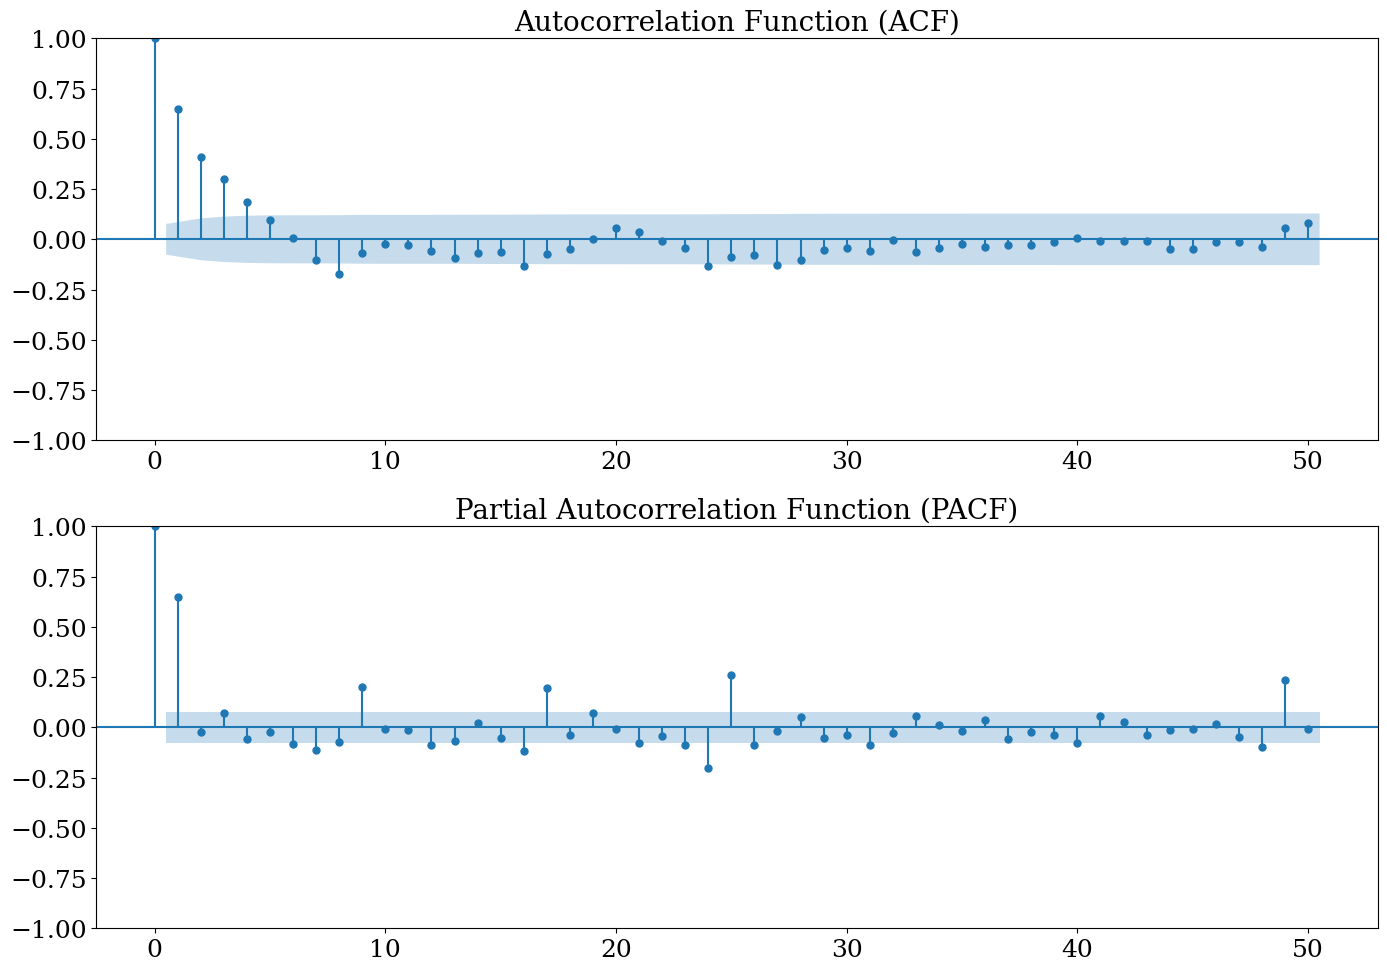

In [104]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(train_data['Target'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(train_data['Target'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file
plt.savefig("acf_gh2.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()

In [105]:
data=datat

# MODEL 1 : NO FEATURE SARIMA

In [106]:
start_time=time.time()

In [107]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

                                      SARIMAX Results                                      
Dep. Variable:                              Target   No. Observations:                  655
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 8)   Log Likelihood               -2299.494
Date:                             Tue, 22 Apr 2025   AIC                           4606.988
Time:                                     23:32:17   BIC                           4624.926
Sample:                                          0   HQIC                          4613.943
                                             - 655                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7570      0.024     31.565      0.000       0.710       0.804
ar.S.L8        0.2977      

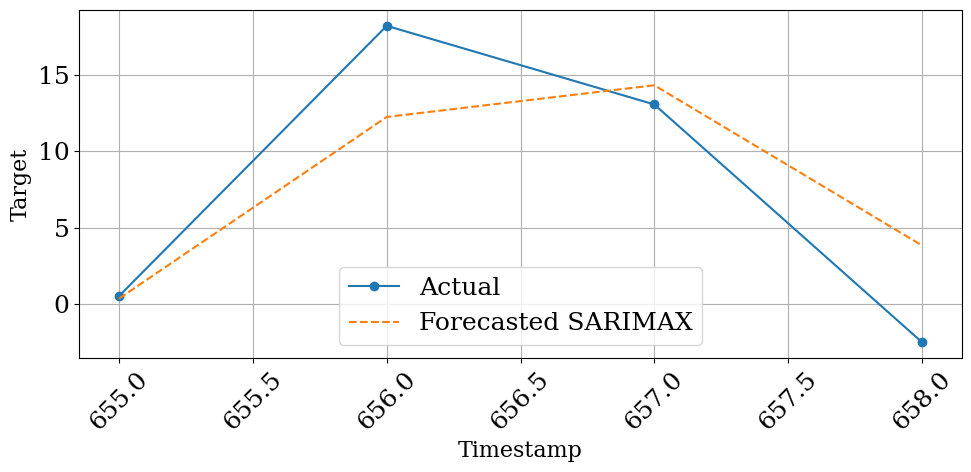

MAE: 3.42, MAPE: 0.82


In [108]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Ensure data is sorted
train_data = train_data.sort_index()
test_data = test_data.sort_index()

# Fit SARIMAX model with combined Fourier terms
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0),  # AR(4) with no differencing
                seasonal_order=(1, 0, 1, 8)
                )  
sarimax_results = model.fit(disp=False)
print(sarimax_results.summary())
# Forecast using combined Fourier terms
sarimax_forecast = sarimax_results.get_forecast(steps=len(test_data)).predicted_mean


# Evaluation metrics
sarimax_mae = mean_absolute_error(test_data['Target'], sarimax_forecast)
sarimax_mape = mean_absolute_percentage_error(test_data['Target'], sarimax_forecast)


# Plot results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarimax_forecast, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print evaluation metrics
print(f"MAE: {sarimax_mae:.2f}, MAPE: {sarimax_mape:.2f}")


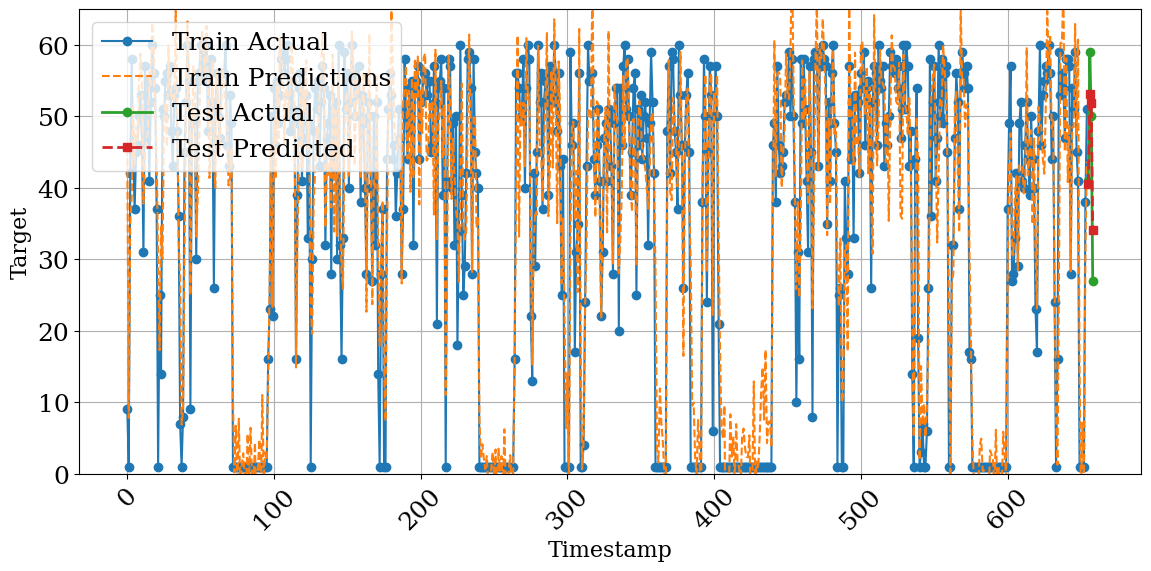

Train MAE: 6.0743
Train MAPE: 5.1829
Test MAE: 4.1726
Test MAPE: 1.5496


In [109]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(4, 0, 0),  # AR(4) with no differencing
                seasonal_order=(1, 0, 1, 8)
                )  
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                      )

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data))
test_predictions = sarima_forecast.predicted_mean


# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

combined_train_predictions = decompose_df['total'].iloc[24:].reset_index(drop=True) + train_predictions.reset_index(drop=True)

# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, data_master_train['Operation'].iloc[24:], label='Train Actual', color='#1f77b4', marker='o')
plt.plot(train_data.index, combined_train_predictions , label='Train Predictions', color='#ff7f0e', linestyle='--')
plt.plot(test_data.index, data_master_test['Operation'], label='Test Actual ', linestyle='-',color='#2ca02c', marker='o', linewidth=2)
plt.plot(test_data.index, predicted, label='Test Predicted', marker='s', color='#d62728', linestyle='--', linewidth=2)
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(0, 65)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     40.491818
1     53.048322
2     51.923174
3     34.149361
MAE: 3.88
MAPE: 10.41%


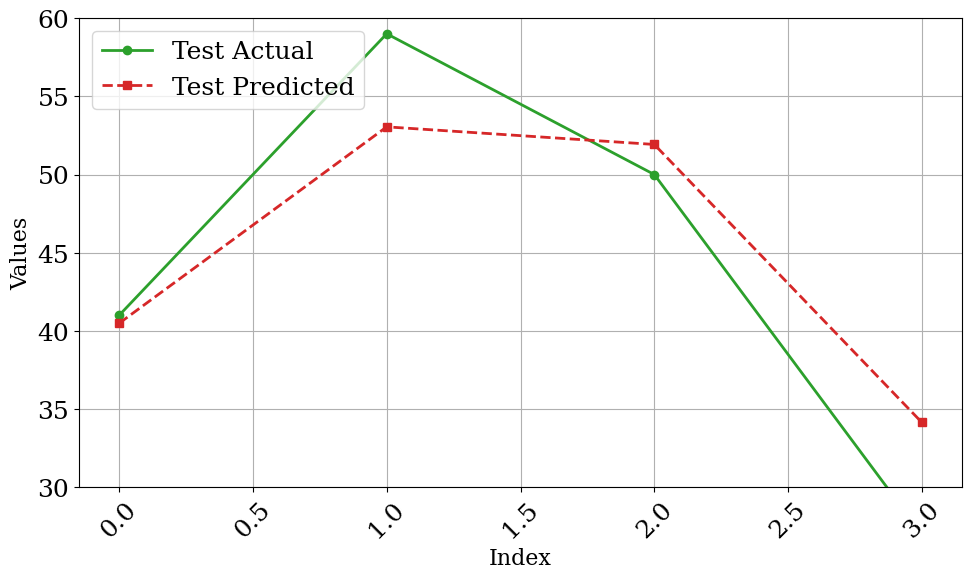

In [110]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()



In [111]:
end_time=time.time()

In [112]:
Cost=end_time-start_time

In [113]:
main_results = update_results(main_results, 'SARIMA by DECOMPOSITION W NO FEATURE ', mae, mape,Cost)

In [114]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295000
1,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,2.764303


### TOPOLOGICAL DATASET

In [115]:
main_results = update_results(main_results, 'Topological Dataset','0' ,'0','0' )

In [116]:
data=datat

# MODEL 2 : SARIMA W ALL FEATURES

In [117]:
start_time=time.time()

In [118]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

In [119]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [120]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


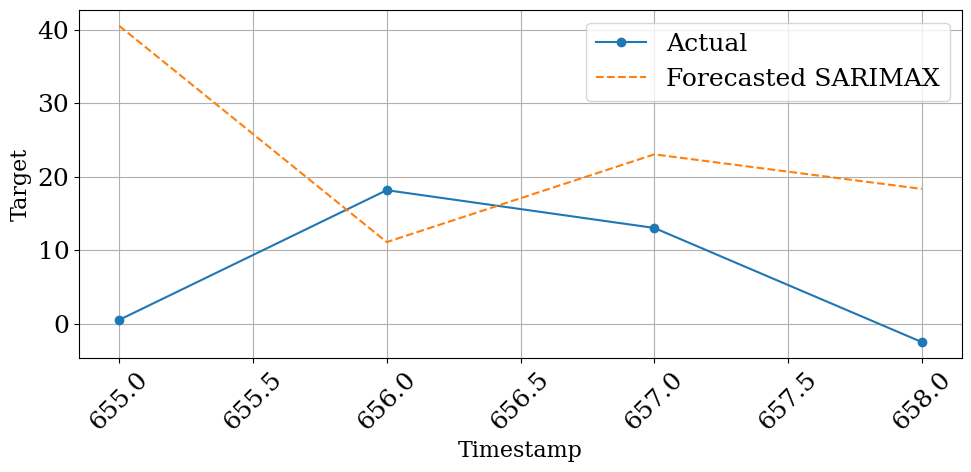

(19.464456549396992, 20.771747988784767)

In [121]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


D:\Users\ar600780\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


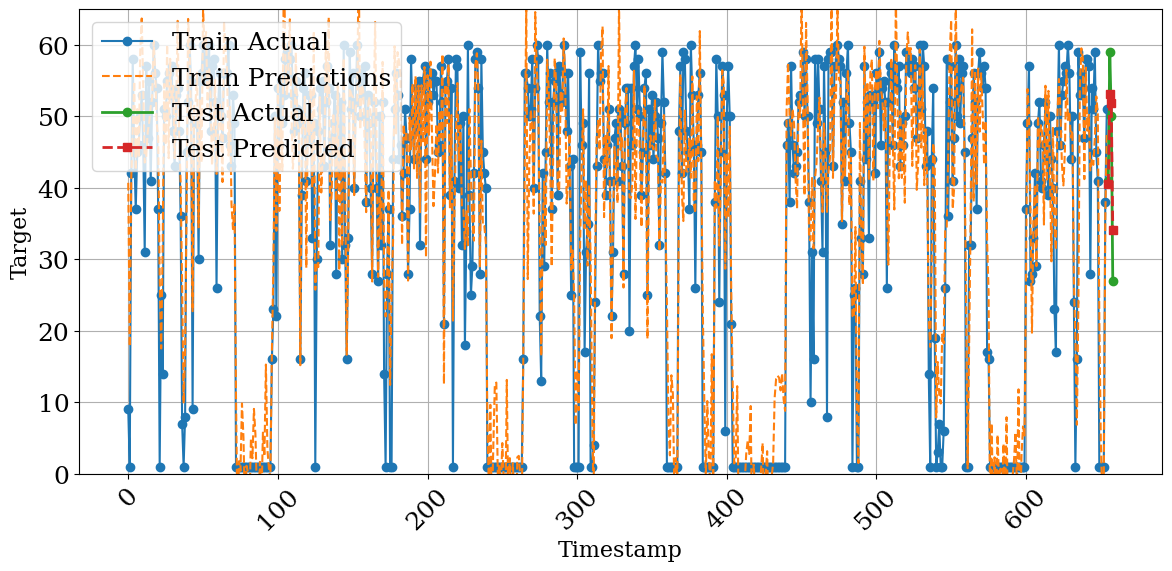

Train MAE: 6.8618
Train MAPE: 11.1008
Test MAE: 19.4645
Test MAPE: 20.7717


In [122]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

combined_train_predictions = decompose_df['total'].iloc[24:].reset_index(drop=True) + train_predictions.reset_index(drop=True)

# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, data_master_train['Operation'].iloc[24:], label='Train Actual', color='#1f77b4', marker='o')
plt.plot(train_data.index, combined_train_predictions , label='Train Predictions', color='#ff7f0e', linestyle='--')
plt.plot(test_data.index, data_master_test['Operation'], label='Test Actual ', linestyle='-',color='#2ca02c', marker='o', linewidth=2)
plt.plot(test_data.index, predicted, label='Test Predicted', marker='s', color='#d62728', linestyle='--', linewidth=2)
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(0, 65)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     80.638666
1     51.942152
2     60.671432
3     48.653513
MAE: 19.76
MAPE: 52.55%


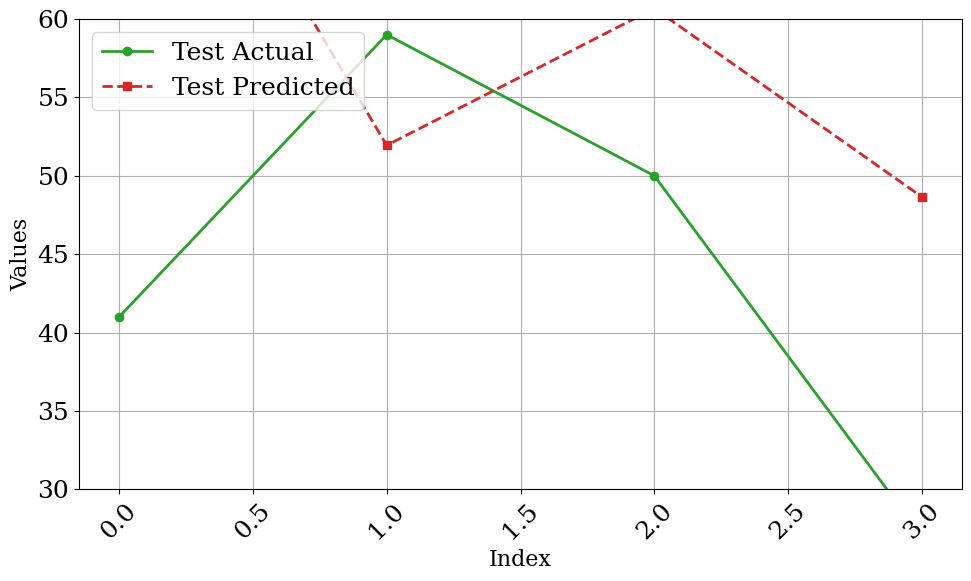

In [123]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()



In [124]:
end_time=time.time()

In [125]:
Cost = end_time - start_time

In [126]:
main_results = update_results(main_results, 'SARIMA W ALL FEATUREs', mae, mape,Cost)

In [127]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295
1,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,2.764303
2,Topological Dataset,0,0,0
3,SARIMA W ALL FEATUREs,19.755365,0.525458,79.955089


# MODEL 3-1 : SARIMA W RFE FEATURES

In [128]:
start_time=time.time()

In [129]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.utils import resample
import time
import warnings
import multiprocessing
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

start_time = time.time()

# Load dataset
df = data  # <-- make sure `data` is defined
target_column = "Target"
exog_columns = [col for col in df.columns if col != target_column]

# Split into training
train_df = df.iloc[:-4]
X_train = train_df[exog_columns]
y_train = train_df[target_column]

# SARIMAX p-value extractor
def get_p_values(X, y):
    try:
        model = SARIMAX(y, 
                        order=(1, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X)
        result = model.fit(disp=False)
        return result.pvalues.loc[X.columns]
    except Exception as e:
        print("SARIMAX fit error:", e)
        return pd.Series([1.0] * X.shape[1], index=X.columns)

# Model AIC calculator
def compute_aic(feature_set):
    try:
        model = SARIMAX(y_train, 
                        order=(1, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X_train[list(feature_set)])
        result = model.fit(disp=False)
        return (feature_set, result.aic)
    except:
        return (feature_set, np.inf)

# RFE parameters
selected_features = exog_columns.copy()
step2 = 5

# RFE Loop
while True:
    p_values = get_p_values(X_train[selected_features], y_train)

    # Features with p > 0.05
    worst_candidates = p_values[p_values > 0.05]

    # Stopping criterion
    if len(worst_candidates) < step2:
        print(f"Stopping early: Only {len(worst_candidates)} features have p > 0.05.")
        break

    # Dynamic step size
    step = min(20, len(worst_candidates), len(selected_features) // 2)

    # Worst features sorted by p-value
    worst_features = worst_candidates.sort_values(ascending=False).head(step).index

    for feature in worst_features:
        if feature in selected_features:
            selected_features.remove(feature)
            print(f"Removed Feature: {feature}, p-value: {p_values[feature]}")

print("\nInitial RFE Completed.")
print(f"Remaining Features: {len(selected_features)}")

# Optional: Stability Check via Bootstrapping
print("\nRunning stability check (bootstrap p-values)...")
bootstrap_rounds = 10
stable_features = []

boot_results = []
for i in range(bootstrap_rounds):
    X_res, y_res = resample(X_train[selected_features], y_train)
    p_vals = get_p_values(X_res, y_res)
    significant = set(p_vals[p_vals < 0.05].index)
    boot_results.append(significant)

stable_features = list(set.intersection(*boot_results))
print(f"\nStable Features Across {bootstrap_rounds} Bootstraps: {len(stable_features)}")

# Optional: AIC comparison for final selection
print("\nEvaluating AIC on stable subsets...")
feature_sets = [stable_features, selected_features]  # Compare both
num_cores = multiprocessing.cpu_count()

aic_values = Parallel(n_jobs=num_cores)(
    delayed(compute_aic)(f_set) for f_set in feature_sets
)

best_features, best_aic = sorted(aic_values, key=lambda x: x[1])[0]
print(f"\nBest AIC: {best_aic}")
print("Selected Final Features:", best_features)


Removed Feature: Col30_L2_H1, p-value: 0.982973519009764
Removed Feature: Col56_L1_H1, p-value: 0.9824525623360651
Removed Feature: Col80_L2_H0, p-value: 0.9770000846977867
Removed Feature: Col46_L2_H1, p-value: 0.9664833784249721
Removed Feature: Col78_L1_H0, p-value: 0.9504157371705009
Removed Feature: Col29_L1_H1, p-value: 0.9479854769022059
Removed Feature: Col15_L2_H0, p-value: 0.9291537694500107
Removed Feature: Col34_L1_H1, p-value: 0.922114858746058
Removed Feature: Col68_L1_H1, p-value: 0.9066820942131206
Removed Feature: Col28_L1_H0, p-value: 0.8887464670931746
Removed Feature: Col60_L2_H0, p-value: 0.8821713954866183
Removed Feature: Col64_L2_H0, p-value: 0.8805474449152644
Removed Feature: silhouette_features_L2_H0_SI, p-value: 0.8674824421394236
Removed Feature: Col54_L1_H1, p-value: 0.8566993475106127
Removed Feature: Col51_L2_H1, p-value: 0.8550862450195031
Removed Feature: Col33_L1_H0, p-value: 0.8390036209640555
Removed Feature: Col32_L2_H1, p-value: 0.8352809264312873

In [130]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

data_rfe = data[columns_to_keep]

In [131]:
data_rfe

,betti_L2_H0,L1_H0,Col4_L2_H0,Col5_L1_H0,Col5_L2_H0,Col6_L1_H0,Col6_L2_H0,Col7_L1_H0,Col7_L2_H0,Col8_L1_H0,...,Col88_L2_H1,Col93_L1_H1,Col94_L1_H1,Col95_L1_H1,Col96_L1_H1,Col97_L1_H1,Col99_L2_H1,dim_0_median_lifetime,dim_0_carlsson_f5,Target
0,0.289040,0.671865,0.751978,0.828142,0.778488,0.873733,0.856326,0.873505,0.756762,0.861010,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.224633,0.098614,-36.630516
1,0.389639,0.784918,0.623555,0.915081,0.620170,0.916890,0.641286,0.844655,0.554010,0.761852,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.248784,0.675501,-32.755274
2,0.379624,0.777805,0.645319,0.915486,0.644582,0.925529,0.672859,0.868392,0.587565,0.802653,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.248784,0.613014,-16.242944
3,0.458352,0.884161,0.590449,0.977780,0.568589,0.929920,0.529891,0.778318,0.400278,0.621735,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.269650,0.270372,6.891582
4,0.529010,0.903267,0.389432,0.976562,0.354078,0.907276,0.316272,0.714620,0.250748,0.507813,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.284929,0.420537,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.888381,0.998306,0.446668,0.994023,0.411135,0.839595,0.336796,0.491017,0.188570,0.103697,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.768420,0.475822,0.412770
655,0.898200,1.000000,0.564590,0.993631,0.536697,0.837416,0.456026,0.484490,0.258456,0.089984,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.737455,0.475822,0.543904
656,0.839722,0.993651,0.464090,0.995018,0.429649,0.846431,0.354490,0.509959,0.199502,0.138911,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.673147,0.475822,18.180364
657,0.894935,0.993655,0.355887,0.995018,0.314437,0.846431,0.245102,0.509959,0.135409,0.138911,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.818619,0.489660,13.045591


In [132]:
train_data = data_rfe[:-4]  # Last 4 rows for testing
test_data = data_rfe[-4:]

In [133]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [134]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

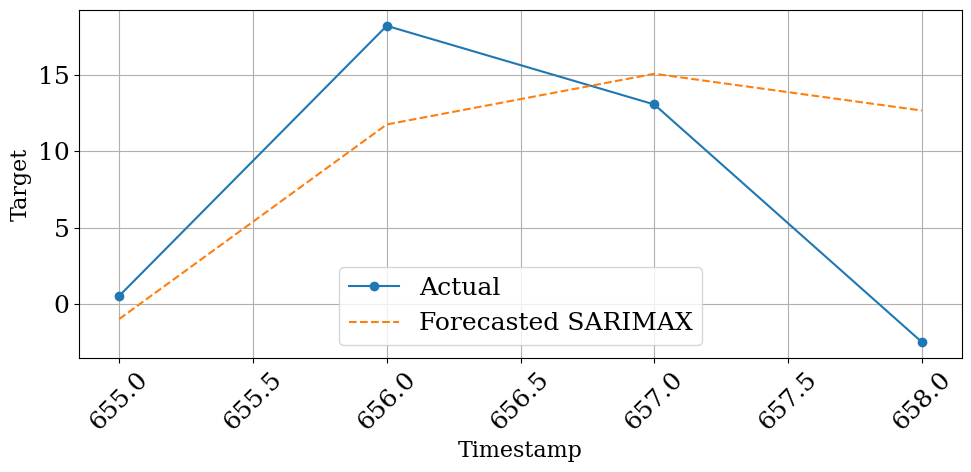

(6.268224264435276, 2.351005074673)

In [135]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


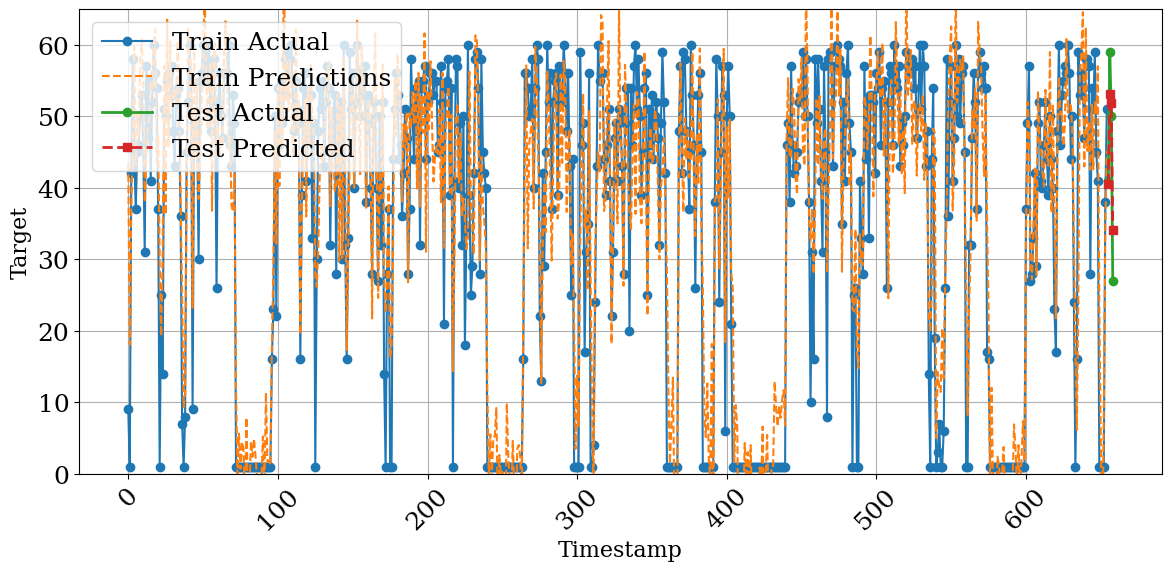

Train MAE: 6.8599
Train MAPE: 2.9477
Test MAE: 6.2682
Test MAPE: 2.3510


In [136]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

combined_train_predictions = decompose_df['total'].iloc[24:].reset_index(drop=True) + train_predictions.reset_index(drop=True)

# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, data_master_train['Operation'].iloc[24:], label='Train Actual', color='#1f77b4', marker='o')
plt.plot(train_data.index, combined_train_predictions , label='Train Predictions', color='#ff7f0e', linestyle='--')
plt.plot(test_data.index, data_master_test['Operation'], label='Test Actual ', linestyle='-',color='#2ca02c', marker='o', linewidth=2)
plt.plot(test_data.index, predicted, label='Test Predicted', marker='s', color='#d62728', linestyle='--', linewidth=2)
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(0, 65)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     39.150375
1     52.559171
2     52.673610
3     42.952661
MAE: 6.73
MAPE: 19.96%


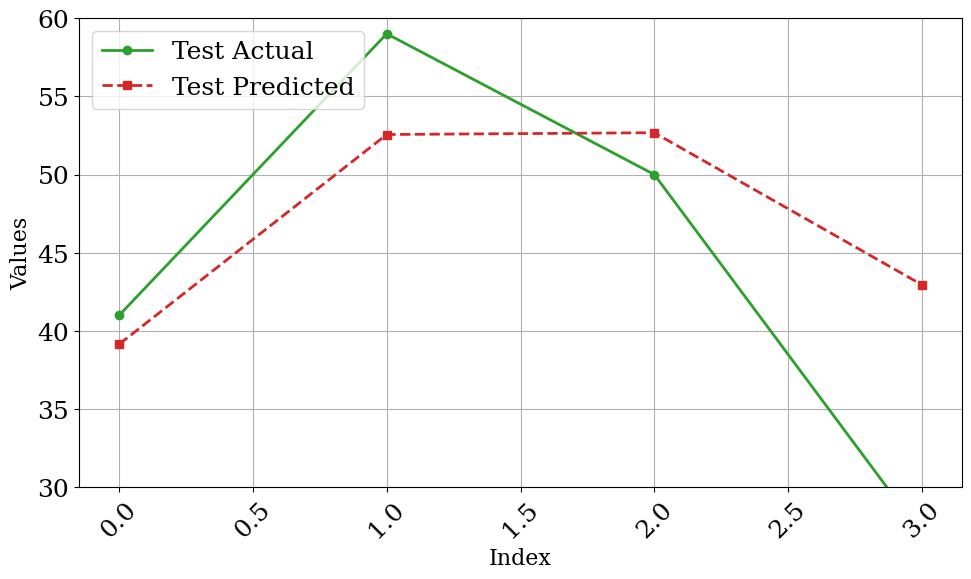

In [137]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [138]:
end_time=time.time()

In [139]:
Cost = end_time - start_time

In [140]:
main_results = update_results(main_results, 'SARIMA W RFE FEATUREs', mae, mape,Cost)

In [141]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295
1,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,2.764303
2,Topological Dataset,0,0,0
3,SARIMA W ALL FEATUREs,19.755365,0.525458,79.955089
4,SARIMA W RFE FEATUREs,6.729181,0.199648,402.748456


# MODEL 4 : SARIMA W RFE + PSO FEATURES

In [142]:
import numpy as np 
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pyswarm import pso  # Particle Swarm Optimization
from functools import lru_cache
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
start_time=time.time()
# Suppress warnings
warnings.filterwarnings("ignore")

# ============================
# Data Preparation
# ============================

target_column = 'Target'  # Replace with actual target column
train_data = data_rfe[:-4]  # Use all but the last 4 rows for training

selected_columns_train = train_data.drop(columns=[target_column])  # Features only
exog_train = selected_columns_train.values

num_features = selected_columns_train.shape[1]  # Number of features

# ============================
# Caching for Faster Execution
# ============================

solution_cache = {}

@lru_cache(maxsize=1000)
def evaluate_solution(solution_key):
    """
    Evaluates SARIMAX performance for a given feature subset using negative BIC.
    """
    selected_features = np.array(solution_key, dtype=bool)
    
    # Penalize solutions that select no features
    if not np.any(selected_features):
        return 1e6  

    exog_selected = exog_train[:, selected_features]

    try:
        model = SARIMAX(train_data[target_column],
                        order=(1, 0, 0),
                        seasonal_order=(1, 0, 1, 8),
                        exog=exog_selected,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=0, maxiter=30)  # Lower maxiter for speed
        return results.bic  # Minimize BIC
    except:
        return 1e6  # Strong penalty for errors

# ============================
# Define PSO Objective Function
# ============================

def pso_objective_function(solution):
    """
    Evaluates the fitness of a feature subset for PSO.
    """
    key = tuple(np.round(solution).astype(int))  # Convert to binary feature selection
    
    if key in solution_cache:
        return solution_cache[key]

    # Evaluate solution
    fitness_val = evaluate_solution(key)
    solution_cache[key] = fitness_val  # Store in cache
    return fitness_val

# ============================
# PSO Execution
# ============================

lb = [0] * num_features  # Lower bounds (0 = feature not selected)
ub = [1] * num_features  # Upper bounds (1 = feature selected)

selected_features_runs = []
best_results = []
num_columns = data_rfe.shape[1]-1
for run in range(5):
    print(f"Starting PSO optimization, run {run+1}...")

    best_solution, best_bic = best_solution, best_bic = pso(
    pso_objective_function, 
    lb, 
    ub, 
    swarmsize=40, 
    maxiter=100, 
    omega=0.7,  # Inertia weight
    phip=1.4,   # Cognitive parameter (similar to c1)
    phig=1.8,   # Social parameter (similar to c2)
    debug=False
)


    # Convert solution to selected feature names
    selected_features_mask = np.round(best_solution).astype(int).astype(bool)
    selected_features_pso = selected_columns_train.columns[selected_features_mask].tolist()
    selected_features_runs.append(selected_features_pso)

    # Fit final model with selected features
    exog_train_final = exog_train[:, selected_features_mask]


    final_model = SARIMAX(train_data[target_column],
                          order=(1, 0, 0),
                          seasonal_order=(1, 0, 1, 8),
                          exog=exog_train_final)
    final_results = final_model.fit(disp=False)
    


    # Save best results
    best_results.append({
        "Run": run + 1,
        "BIC": best_bic,
        "Selected Features": selected_features_pso
    })

# Convert to DataFrame
results_df = pd.DataFrame(best_results)

# Identify the best run (minimum BIC)
best_run = results_df.loc[results_df[['BIC']].sum(axis=1).idxmin()]
best_run_features = best_run["Selected Features"]

# Find the most frequently chosen features (chosen in at least 3 runs)
feature_counts = Counter(feature for run_features in selected_features_runs for feature in run_features)
final_feature_selection = list(feature_counts.keys())

# If final_feature_selection is empty, assign it to best_run_features
if not final_feature_selection:
    final_feature_selection = best_run_features

# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

# ============================
# Display Results
# ============================

print("\nPSO Runs Results:")
print(results_df)

print("\nBest Run Summary:")
print(best_run)

print("\nFinal Feature Selection (Chosen in at least 3 runs or from best run if empty):")
print(final_feature_selection_list)

print("\nBest Run Features List:")
print(best_run_feature_list)

# ============================
# Save Results
# ============================

# Convert to DataFrame for easy export if needed
best_run_summary_df = pd.DataFrame([best_run])
final_features_df = pd.DataFrame({"Most Chosen Features": final_feature_selection_list})


Starting PSO optimization, run 1...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 2...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 3...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 4...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 5...
Stopping search: maximum iterations reached --> 100

PSO Runs Results:
   Run          BIC                                  Selected Features
0    1  4705.157059  [betti_L2_H0, Col5_L1_H0, Col5_L2_H0, Col7_L1_...
1    2  4678.268592  [betti_L2_H0, L1_H0, Col6_L1_H0, Col6_L2_H0, C...
2    3  4673.473008  [Col4_L2_H0, Col5_L1_H0, Col5_L2_H0, Col6_L1_H...
3    4  4684.246441  [Col5_L1_H0, Col6_L1_H0, Col41_L1_H0, Col53_L2...
4    5  4672.179305  [betti_L2_H0, Col5_L1_H0, Col6_L1_H0, Col7_L1_...

Best Run Summary:
Run                                                                  5
BIC                      

In [143]:
# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

In [144]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = best_run_feature_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [145]:
data_pso=data_rfe[selected_features_pso]

In [146]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = final_feature_selection_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [147]:
data_pso_best=data_rfe[selected_features_pso]

In [148]:
train_data = data_pso[:-4]  # Last 4 rows for testing
test_data = data_pso[-4:]

In [149]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [150]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

In [151]:
start_time=time.time()

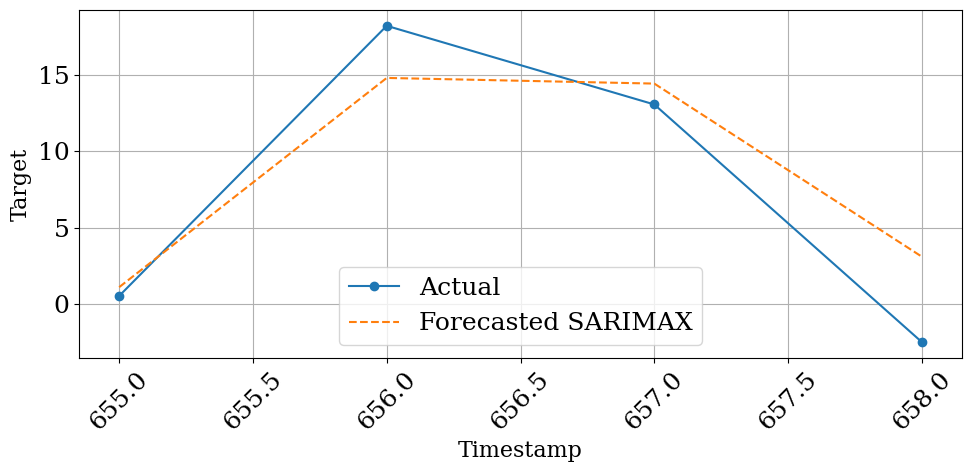

(2.7281614103908773, 0.8998987749917802)

In [152]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


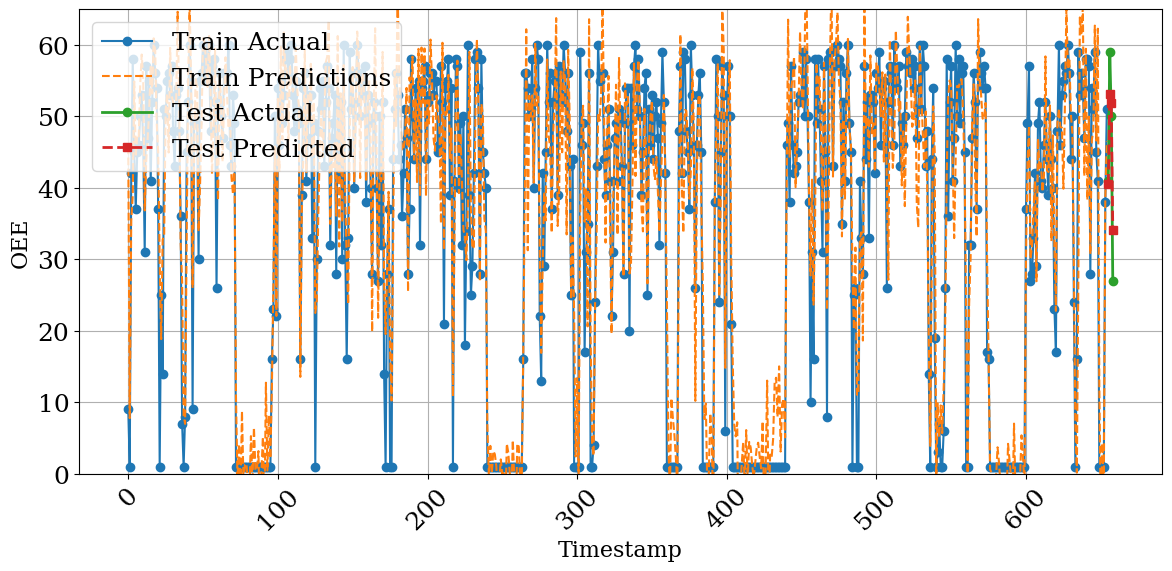

Train MAE: 6.1494
Train MAPE: 6.2204
Test MAE: 2.7282
Test MAPE: 0.8999


In [153]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

combined_train_predictions = decompose_df['total'].iloc[24:].reset_index(drop=True) + train_predictions.reset_index(drop=True)

# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, data_master_train['Operation'].iloc[24:], label='Train Actual', color='#1f77b4', marker='o')
plt.plot(train_data.index, combined_train_predictions , label='Train Predictions', color='#ff7f0e', linestyle='--')
plt.plot(test_data.index, data_master_test['Operation'], label='Test Actual ', linestyle='-',color='#2ca02c', marker='o', linewidth=2)
plt.plot(test_data.index, predicted, label='Test Predicted', marker='s', color='#d62728', linestyle='--', linewidth=2)
 
plt.xlabel('Timestamp')
plt.ylabel('OEE')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(0, 65)
# Save the figure as an SVG file
plt.savefig("0_best_h2.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     41.231350
1     55.597201
2     52.032629
3     33.409500
MAE: 3.02
MAPE: 8.53%


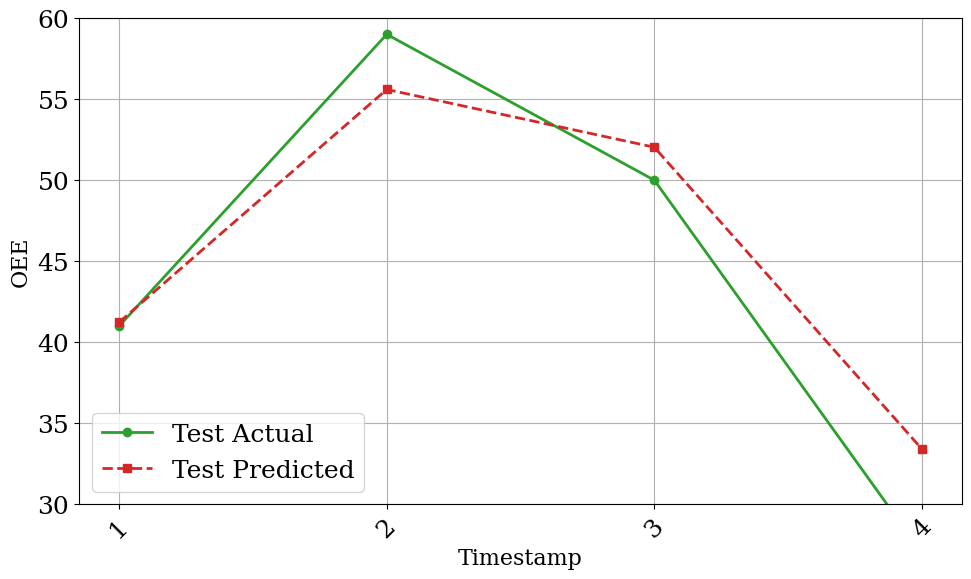

In [154]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")
x_vals = range(1, len(test) + 1)
# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(x_vals, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(x_vals, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')
plt.xticks(ticks=x_vals) 
plt.xlabel('Timestamp')
plt.ylabel('OEE')
plt.xticks(rotation=45)
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
# Save the figure as an SVG file
plt.savefig("2_best_h2.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')
plt.show()


In [155]:
end_time=time.time()

In [156]:
Cost = end_time - start_time

In [157]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO FEATUREs', mae, mape,Cost)

In [158]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295
1,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,2.764303
2,Topological Dataset,0,0,0
3,SARIMA W ALL FEATUREs,19.755365,0.525458,79.955089
4,SARIMA W RFE FEATUREs,6.729181,0.199648,402.748456
5,SARIMA W RFE + PSO FEATUREs,3.019069,0.08534,10.604915


# MODEL 4 - 1: SARIMA W RFE+PSO BEST FEATURE SELECTION

In [159]:
start_time=time.time()

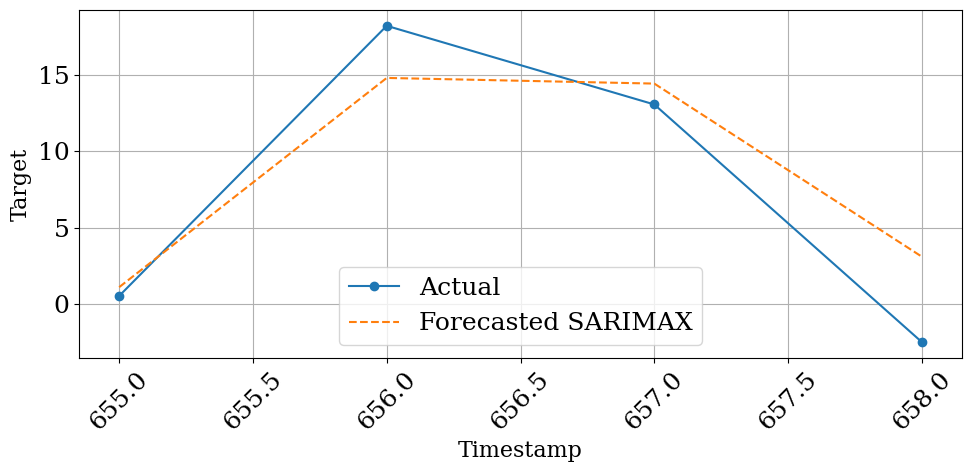

(2.7281614103908773, 0.8998987749917802)

In [160]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


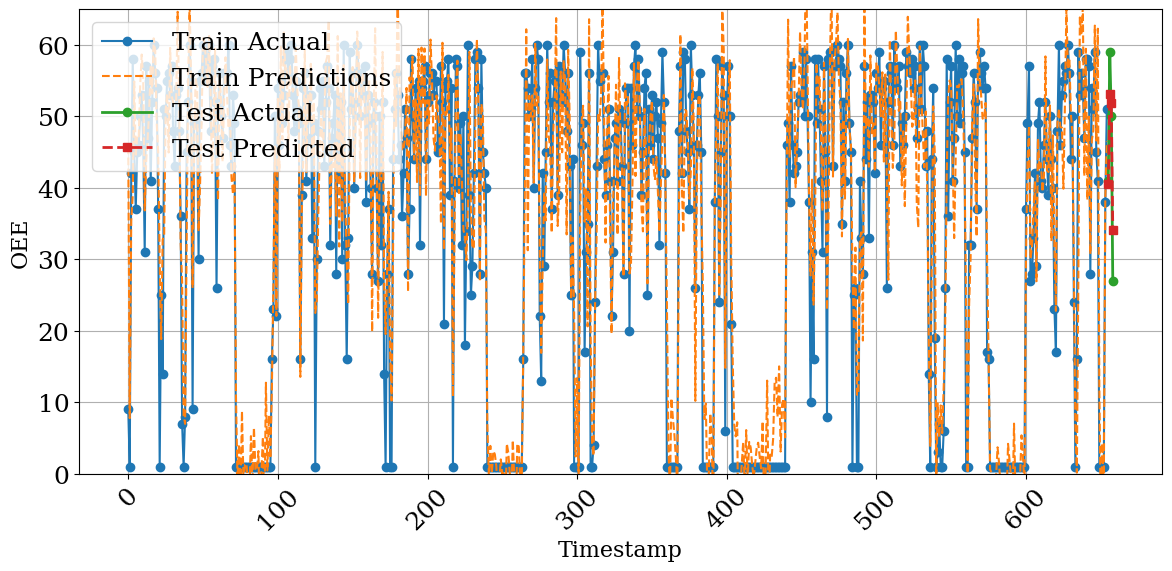

Train MAE: 6.1494
Train MAPE: 6.2204
Test MAE: 2.7282
Test MAPE: 0.8999


In [161]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

combined_train_predictions = decompose_df['total'].iloc[24:].reset_index(drop=True) + train_predictions.reset_index(drop=True)

# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, data_master_train['Operation'].iloc[24:], label='Train Actual', color='#1f77b4', marker='o')
plt.plot(train_data.index, combined_train_predictions , label='Train Predictions', color='#ff7f0e', linestyle='--')
plt.plot(test_data.index, data_master_test['Operation'], label='Test Actual ', linestyle='-',color='#2ca02c', marker='o', linewidth=2)
plt.plot(test_data.index, predicted, label='Test Predicted', marker='s', color='#d62728', linestyle='--', linewidth=2)
 
plt.xlabel('Timestamp')
plt.ylabel('OEE')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(0, 65)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     41.231350
1     55.597201
2     52.032629
3     33.409500
MAE: 3.02
MAPE: 8.53%


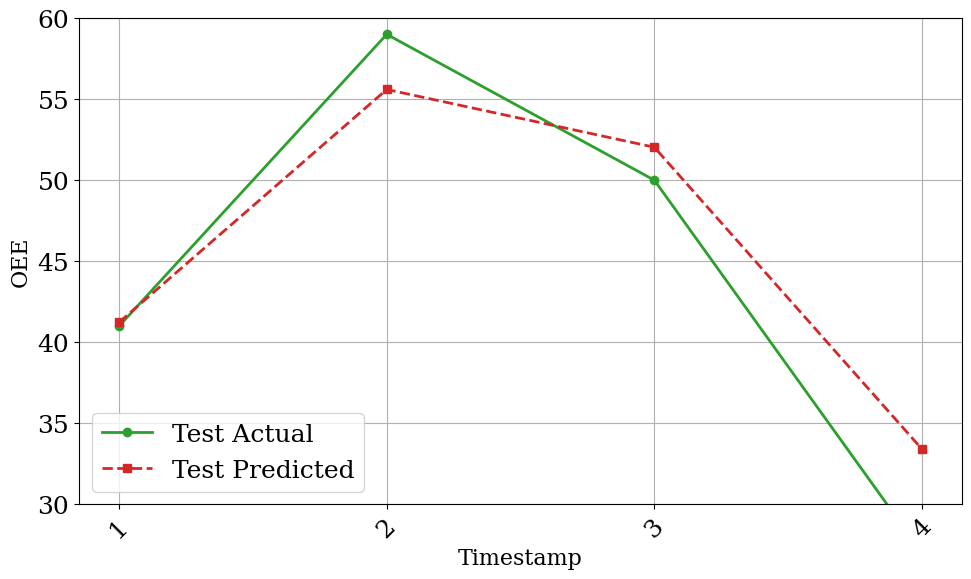

In [162]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")
x_vals = range(1, len(test) + 1)
# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(x_vals, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(x_vals, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')
plt.xticks(ticks=x_vals) 
plt.xlabel('Timestamp')
plt.ylabel('OEE')
plt.xticks(rotation=45)
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [163]:
end_time=time.time()

In [164]:
Cost = end_time - start_time

In [165]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO BEST FEATUREs', mae, mape,Cost)

In [166]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295
1,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,2.764303
2,Topological Dataset,0,0,0
3,SARIMA W ALL FEATUREs,19.755365,0.525458,79.955089
4,SARIMA W RFE FEATUREs,6.729181,0.199648,402.748456
5,SARIMA W RFE + PSO FEATUREs,3.019069,0.08534,10.604915
6,SARIMA W RFE + PSO BEST FEATUREs,3.019069,0.08534,11.073368


# STATISTICAL DATASET

In [167]:
main_results = update_results(main_results, 'Topological Dataset','0' ,'0','0' )

In [168]:
data=datas

# MODEL 2 : SARIMA W ALL FEATURES

In [169]:
start_time=time.time()

In [170]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

In [171]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [172]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

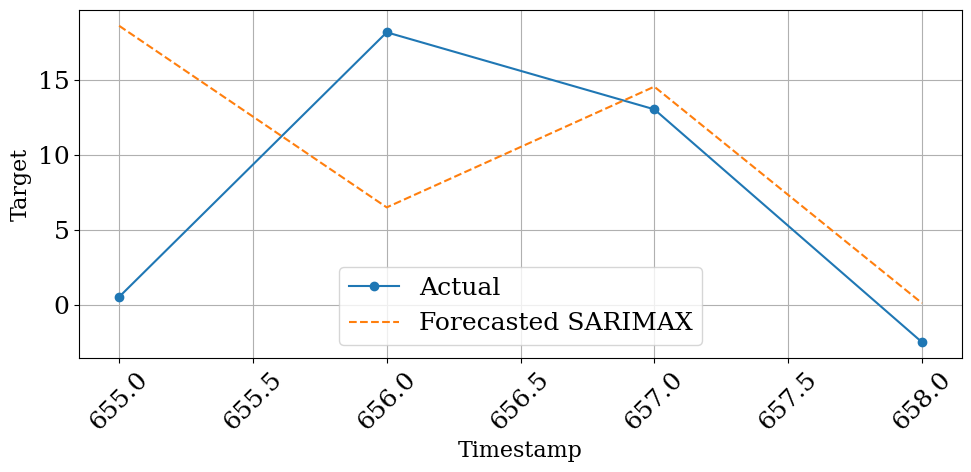

(8.464130994947832, 8.758326647501999)

In [173]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


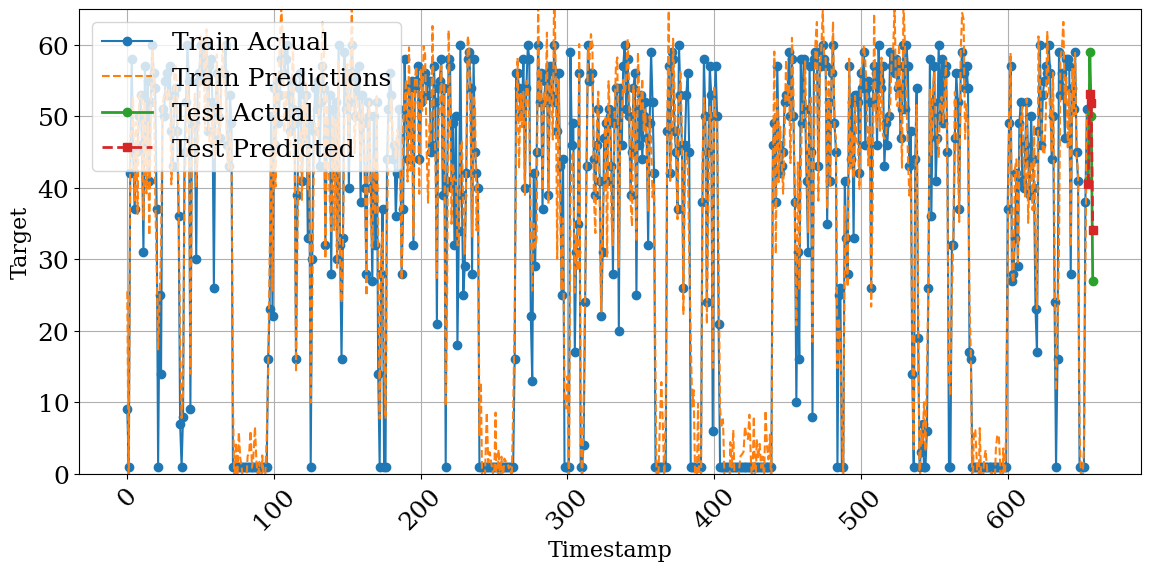

Train MAE: 4.8925
Train MAPE: 3.3975
Test MAE: 8.4641
Test MAPE: 8.7583


In [174]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

combined_train_predictions = decompose_df['total'].iloc[24:].reset_index(drop=True) + train_predictions.reset_index(drop=True)

# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, data_master_train['Operation'].iloc[24:], label='Train Actual', color='#1f77b4', marker='o')
plt.plot(train_data.index, combined_train_predictions , label='Train Predictions', color='#ff7f0e', linestyle='--')
plt.plot(test_data.index, data_master_test['Operation'], label='Test Actual ', linestyle='-',color='#2ca02c', marker='o', linewidth=2)
plt.plot(test_data.index, predicted, label='Test Predicted', marker='s', color='#d62728', linestyle='--', linewidth=2)
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(0, 65)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     58.728942
1     47.328480
2     52.181467
3     30.438227
MAE: 8.76
MAPE: 20.03%


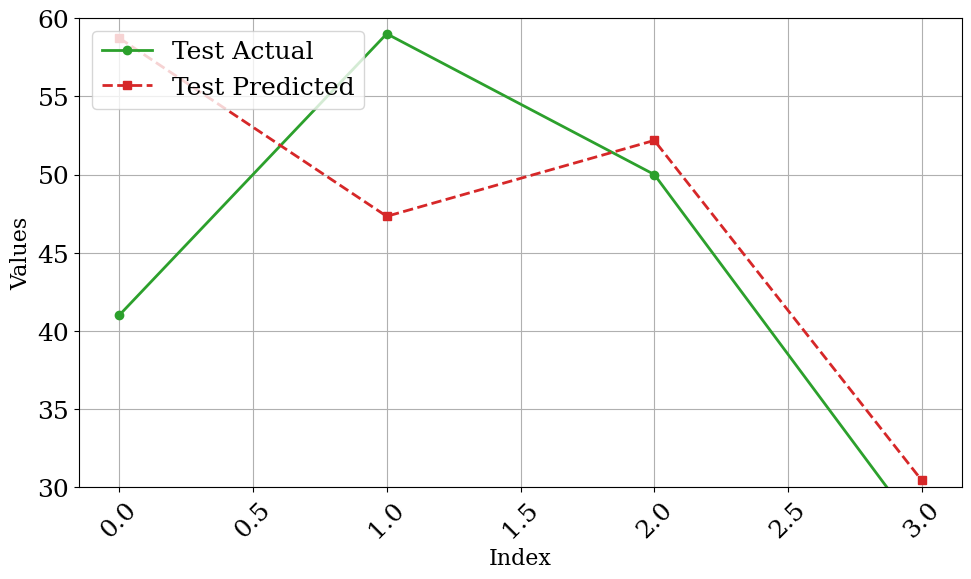

In [175]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [176]:
end_time=time.time()

In [177]:
Cost = end_time - start_time

In [178]:
main_results = update_results(main_results, 'SARIMA W ALL FEATUREs', mae, mape,Cost)

In [179]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295
1,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,2.764303
2,Topological Dataset,0,0,0
3,SARIMA W ALL FEATUREs,19.755365,0.525458,79.955089
4,SARIMA W RFE FEATUREs,6.729181,0.199648,402.748456
5,SARIMA W RFE + PSO FEATUREs,3.019069,0.08534,10.604915
6,SARIMA W RFE + PSO BEST FEATUREs,3.019069,0.08534,11.073368
7,Topological Dataset,0,0,0
8,SARIMA W ALL FEATUREs,8.755039,0.200302,143.152084


# MODEL 3-1 : SARIMA W RFE FEATURES

In [180]:
start_time=time.time()

In [181]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.utils import resample
import time
import warnings
import multiprocessing
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

start_time = time.time()

# Load dataset
df = data  # <-- make sure `data` is defined
target_column = "Target"
exog_columns = [col for col in df.columns if col != target_column]

# Split into training
train_df = df.iloc[:-4]
X_train = train_df[exog_columns]
y_train = train_df[target_column]

# SARIMAX p-value extractor
def get_p_values(X, y):
    try:
        model = SARIMAX(y, 
                        order=(1, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X)
        result = model.fit(disp=False)
        return result.pvalues.loc[X.columns]
    except Exception as e:
        print("SARIMAX fit error:", e)
        return pd.Series([1.0] * X.shape[1], index=X.columns)

# Model AIC calculator
def compute_aic(feature_set):
    try:
        model = SARIMAX(y_train, 
                        order=(1, 0, 0), 
                        seasonal_order=(1, 0, 1, 8), 
                        exog=X_train[list(feature_set)])
        result = model.fit(disp=False)
        return (feature_set, result.aic)
    except:
        return (feature_set, np.inf)

# RFE parameters
selected_features = exog_columns.copy()
step2 = 5

# RFE Loop
while True:
    p_values = get_p_values(X_train[selected_features], y_train)

    # Features with p > 0.05
    worst_candidates = p_values[p_values > 0.05]

    # Stopping criterion
    if len(worst_candidates) < step2:
        print(f"Stopping early: Only {len(worst_candidates)} features have p > 0.05.")
        break

    # Dynamic step size
    step = min(20, len(worst_candidates), len(selected_features) // 2)

    # Worst features sorted by p-value
    worst_features = worst_candidates.sort_values(ascending=False).head(step).index

    for feature in worst_features:
        if feature in selected_features:
            selected_features.remove(feature)
            print(f"Removed Feature: {feature}, p-value: {p_values[feature]}")

print("\nInitial RFE Completed.")
print(f"Remaining Features: {len(selected_features)}")

# Optional: Stability Check via Bootstrapping
print("\nRunning stability check (bootstrap p-values)...")
bootstrap_rounds = 10
stable_features = []

boot_results = []
for i in range(bootstrap_rounds):
    X_res, y_res = resample(X_train[selected_features], y_train)
    p_vals = get_p_values(X_res, y_res)
    significant = set(p_vals[p_vals < 0.05].index)
    boot_results.append(significant)

stable_features = list(set.intersection(*boot_results))
print(f"\nStable Features Across {bootstrap_rounds} Bootstraps: {len(stable_features)}")

# Optional: AIC comparison for final selection
print("\nEvaluating AIC on stable subsets...")
feature_sets = [stable_features, selected_features]  # Compare both
num_cores = multiprocessing.cpu_count()

aic_values = Parallel(n_jobs=num_cores)(
    delayed(compute_aic)(f_set) for f_set in feature_sets
)

best_features, best_aic = sorted(aic_values, key=lambda x: x[1])[0]
print(f"\nBest AIC: {best_aic}")
print("Selected Final Features:", best_features)


Removed Feature: Operation__cid_ce__normalize_False, p-value: 0.9977856678445137
Removed Feature: Operation__partial_autocorrelation__lag_8, p-value: 0.9971477247295929
Removed Feature: Operation__fft_coefficient__attr_"real"__coeff_4, p-value: 0.992555425829864
Removed Feature: Operation__spkt_welch_density__coeff_2, p-value: 0.9844410326499973
Removed Feature: Operation__ar_coefficient__coeff_3__k_10, p-value: 0.9816729813387804
Removed Feature: Operation__cwt_coefficients__coeff_9__w_2__widths_(2, 5, 10, 20), p-value: 0.9813324477785305
Removed Feature: Operation__ar_coefficient__coeff_2__k_10, p-value: 0.9792543905310169
Removed Feature: Operation__max_langevin_fixed_point__m_3__r_30, p-value: 0.9756945392233015
Removed Feature: Operation__fft_coefficient__attr_"angle"__coeff_3, p-value: 0.9733518282364515
Removed Feature: Operation__cwt_coefficients__coeff_8__w_2__widths_(2, 5, 10, 20), p-value: 0.9727157158753207
Removed Feature: Operation__ar_coefficient__coeff_4__k_10, p-value:

Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_True__qh_0.4__ql_0.0, p-value: 0.8159763034487217
Removed Feature: Operation__change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.2, p-value: 0.7772829914082269
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.4, p-value: 0.7689887580466279
Removed Feature: Operation__number_crossing_m__m_0, p-value: 0.7591231341915223
Removed Feature: Operation__change_quantiles__f_agg_"mean"__isabs_False__qh_0.2__ql_0.0, p-value: 0.75607440456812
Removed Feature: Operation__agg_linear_trend__attr_"stderr"__chunk_len_10__f_agg_"var", p-value: 0.7313249183300515
Removed Feature: Operation__linear_trend__attr_"pvalue", p-value: 0.7195125571498298
Removed Feature: Operation__fft_coefficient__attr_"real"__coeff_11, p-value: 0.7156290924311274
Removed Feature: Operation__sample_entropy, p-value: 0.712637603296695
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_True__qh_0.2__ql_0.0, p-v

Removed Feature: Operation__fft_aggregated__aggtype_"centroid", p-value: 0.7804535466627395
Removed Feature: Operation__index_mass_quantile__q_0.6, p-value: 0.5632855800223173
Removed Feature: Operation__fft_coefficient__attr_"abs"__coeff_12, p-value: 0.41488377500408946
Removed Feature: Operation__spkt_welch_density__coeff_5, p-value: 0.27791717493571855
Removed Feature: Operation__augmented_dickey_fuller__attr_"usedlag"__autolag_"AIC", p-value: 0.2653853270826503
Removed Feature: Operation__fft_coefficient__attr_"abs"__coeff_0, p-value: 0.2540878518816877
Removed Feature: Operation__ratio_beyond_r_sigma__r_0.5, p-value: 0.23836232933967494
Removed Feature: Operation__fft_coefficient__attr_"abs"__coeff_10, p-value: 0.16822153320011857
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6, p-value: 0.16219620931597345
Removed Feature: Operation__agg_autocorrelation__f_agg_"median"__maxlag_40, p-value: 0.15959083521087092
Removed Feature: Operation__fft_

In [182]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

data_rfe = data[columns_to_keep]

In [183]:
data_rfe

,Operation__variance,Operation__kurtosis,Operation__first_location_of_minimum,Operation__minimum,Operation__c3__lag_2,Operation__c3__lag_3,Operation__cid_ce__normalize_True,Operation__large_standard_deviation__r_0.30000000000000004,Operation__autocorrelation__lag_2,Operation__autocorrelation__lag_4,...,"Operation__agg_linear_trend__attr_""slope""__chunk_len_5__f_agg_""var""","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""max""","Operation__agg_linear_trend__attr_""stderr""__chunk_len_5__f_agg_""max""","Operation__agg_linear_trend__attr_""stderr""__chunk_len_10__f_agg_""mean""","Operation__augmented_dickey_fuller__attr_""teststat""__autolag_""AIC""",Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_0,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_1,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_3,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_9,Target
0,0.115800,0.241996,0.608696,0.736691,0.713178,0.726475,0.478533,0,0.732304,0.667920,...,0.488034,0.506061,0.135317,0.228163,0.532393,0.501017,0.212610,0.113616,0.018029,-36.630516
1,0.276186,0.814625,1.000000,0.101781,0.703359,0.712135,0.509238,0,0.516078,0.578727,...,0.808668,0.506061,0.190517,0.102840,0.588588,0.264193,0.142531,0.066542,0.640073,-32.755274
2,0.361447,0.563293,0.956522,0.101781,0.683828,0.678553,0.383007,0,0.438189,0.446990,...,0.848609,0.573029,0.119451,0.141673,0.614267,0.108308,0.122982,0.044238,0.924360,-16.242944
3,0.372947,0.447570,0.913043,0.101781,0.684502,0.666841,0.408672,0,0.561794,0.411802,...,0.748741,0.576647,0.111513,0.224648,0.565750,0.098007,0.106838,0.064205,0.493819,6.891582
4,0.372415,0.448262,0.869565,0.101781,0.669784,0.646126,0.483940,0,0.473252,0.395034,...,0.791988,0.604535,0.124114,0.241058,0.581954,0.110997,0.076961,0.089487,0.115074,-2.448256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,0.697103,0.149290,0.826087,0.153139,0.460751,0.907634,0.389104,0,0.520188,0.477816,...,0.542073,0.124951,0.744567,0.361837,0.566523,0.016110,0.358909,0.081545,0.152297,0.412770
655,0.697851,0.148954,0.782609,0.153139,0.464605,0.888741,0.401063,0,0.507496,0.459679,...,0.392050,0.273481,0.227867,0.155343,0.561089,0.126527,0.283699,0.109601,0.034025,0.543904
656,0.697949,0.148874,0.739130,0.153139,0.469137,0.894254,0.395877,0,0.512554,0.423437,...,0.236790,0.274920,0.087314,0.146578,0.520804,0.131576,0.291301,0.135987,0.000000,18.180364
657,0.739417,0.127158,0.695652,0.153139,0.463273,0.959277,0.373611,0,0.507480,0.369644,...,0.183635,0.468551,0.652691,0.447607,0.814676,0.343776,0.053010,0.055642,0.063021,13.045591


In [184]:
train_data = data_rfe[:-4]  # Last 4 rows for testing
test_data = data_rfe[-4:]

In [185]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [186]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

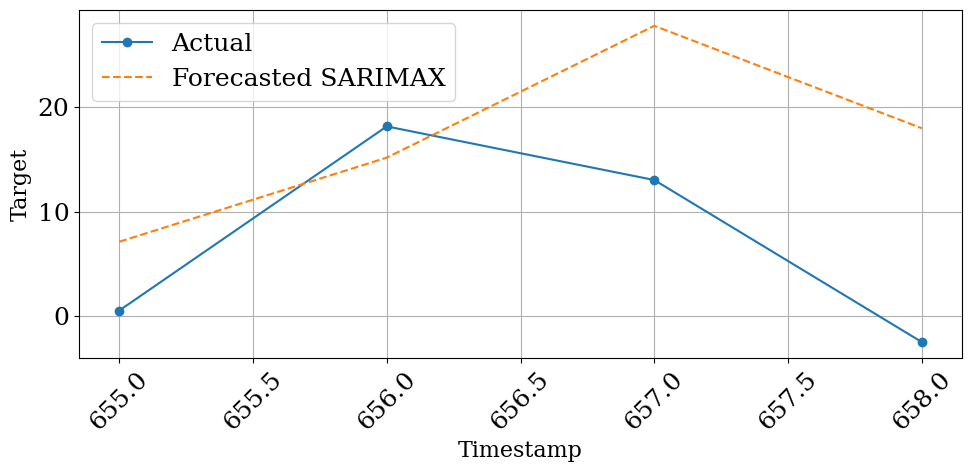

(11.204804810924761, 5.425763818326754)

In [187]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


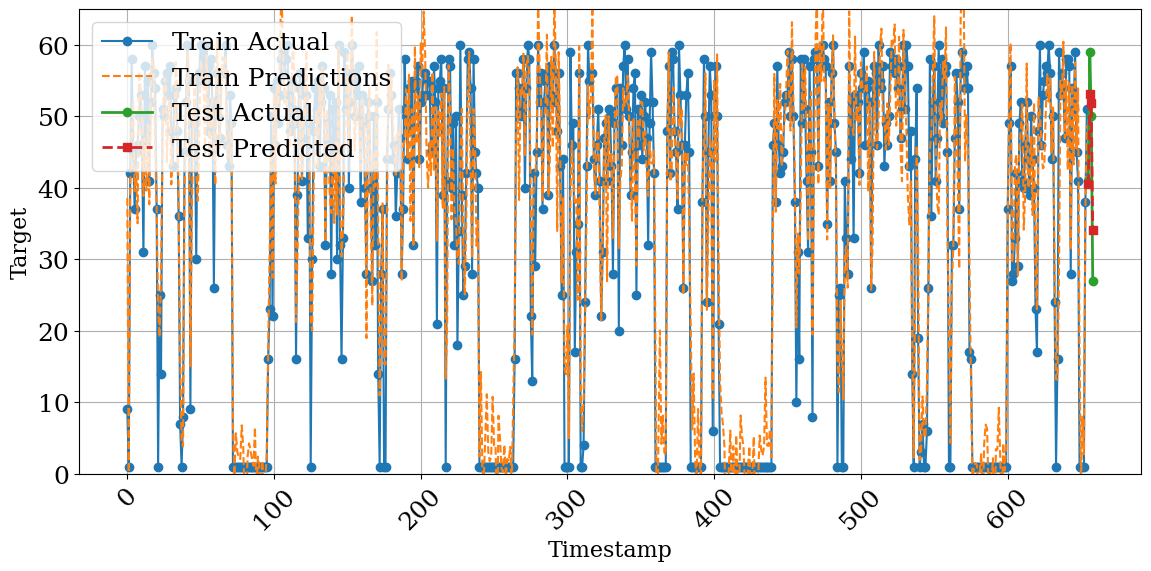

Train MAE: 5.6226
Train MAPE: 5.8864
Test MAE: 11.2048
Test MAPE: 5.4258


In [188]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

combined_train_predictions = decompose_df['total'].iloc[24:].reset_index(drop=True) + train_predictions.reset_index(drop=True)

# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, data_master_train['Operation'].iloc[24:], label='Train Actual', color='#1f77b4', marker='o')
plt.plot(train_data.index, combined_train_predictions , label='Train Predictions', color='#ff7f0e', linestyle='--')
plt.plot(test_data.index, data_master_test['Operation'], label='Test Actual ', linestyle='-',color='#2ca02c', marker='o', linewidth=2)
plt.plot(test_data.index, predicted, label='Test Predicted', marker='s', color='#d62728', linestyle='--', linewidth=2)
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(0, 65)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     47.251358
1     56.009763
2     65.435536
3     48.305721
MAE: 11.50
MAPE: 32.52%


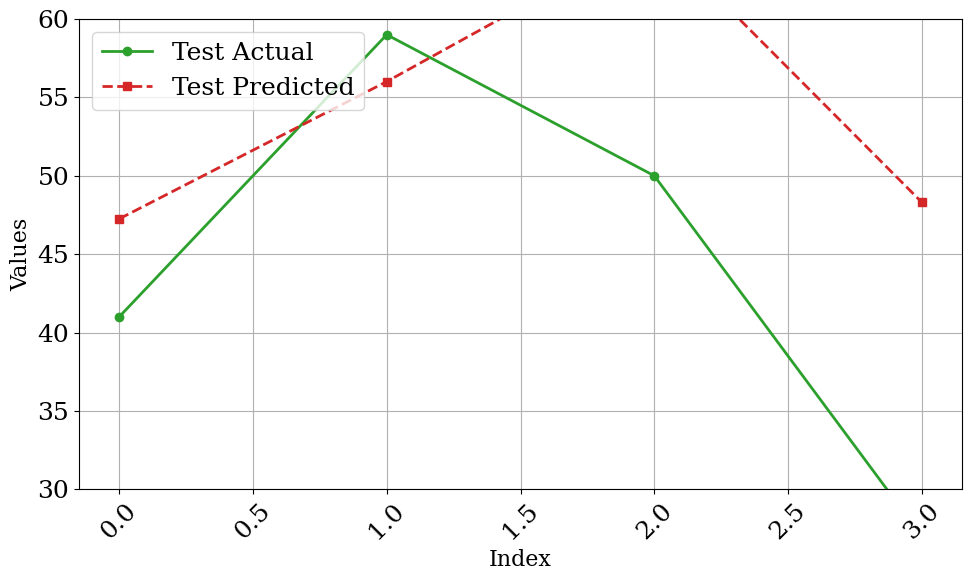

In [189]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [190]:
end_time=time.time()

In [191]:
Cost = end_time - start_time

In [192]:
main_results = update_results(main_results, 'SARIMA W RFE FEATUREs', mae, mape,Cost)

In [193]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295
1,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,2.764303
2,Topological Dataset,0,0,0
3,SARIMA W ALL FEATUREs,19.755365,0.525458,79.955089
4,SARIMA W RFE FEATUREs,6.729181,0.199648,402.748456
5,SARIMA W RFE + PSO FEATUREs,3.019069,0.08534,10.604915
6,SARIMA W RFE + PSO BEST FEATUREs,3.019069,0.08534,11.073368
7,Topological Dataset,0,0,0
8,SARIMA W ALL FEATUREs,8.755039,0.200302,143.152084
9,SARIMA W RFE FEATUREs,11.495713,0.325241,736.31028


# MODEL 4 : SARIMA W RFE + PSO FEATURES

In [194]:
import numpy as np 
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pyswarm import pso  # Particle Swarm Optimization
from functools import lru_cache
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
start_time=time.time()
# Suppress warnings
warnings.filterwarnings("ignore")

# ============================
# Data Preparation
# ============================

target_column = 'Target'  # Replace with actual target column
train_data = data_rfe[:-4]  # Use all but the last 4 rows for training

selected_columns_train = train_data.drop(columns=[target_column])  # Features only
exog_train = selected_columns_train.values

num_features = selected_columns_train.shape[1]  # Number of features

# ============================
# Caching for Faster Execution
# ============================

solution_cache = {}

@lru_cache(maxsize=1000)
def evaluate_solution(solution_key):
    """
    Evaluates SARIMAX performance for a given feature subset using negative BIC.
    """
    selected_features = np.array(solution_key, dtype=bool)
    
    # Penalize solutions that select no features
    if not np.any(selected_features):
        return 1e6  

    exog_selected = exog_train[:, selected_features]

    try:
        model = SARIMAX(train_data[target_column],
                        order=(1, 0, 0),
                        seasonal_order=(1, 0, 1, 8),
                        exog=exog_selected,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=0, maxiter=30)  # Lower maxiter for speed
        return results.bic  # Minimize BIC
    except:
        return 1e6  # Strong penalty for errors

# ============================
# Define PSO Objective Function
# ============================

def pso_objective_function(solution):
    """
    Evaluates the fitness of a feature subset for PSO.
    """
    key = tuple(np.round(solution).astype(int))  # Convert to binary feature selection
    
    if key in solution_cache:
        return solution_cache[key]

    # Evaluate solution
    fitness_val = evaluate_solution(key)
    solution_cache[key] = fitness_val  # Store in cache
    return fitness_val

# ============================
# PSO Execution
# ============================

lb = [0] * num_features  # Lower bounds (0 = feature not selected)
ub = [1] * num_features  # Upper bounds (1 = feature selected)

selected_features_runs = []
best_results = []
num_columns = data_rfe.shape[1]-1
for run in range(5):
    print(f"Starting PSO optimization, run {run+1}...")

    best_solution, best_bic = best_solution, best_bic = pso(
    pso_objective_function, 
    lb, 
    ub, 
    swarmsize=40, 
    maxiter=100, 
    omega=0.7,  # Inertia weight
    phip=1.4,   # Cognitive parameter (similar to c1)
    phig=1.8,   # Social parameter (similar to c2)
    debug=False
)


    # Convert solution to selected feature names
    selected_features_mask = np.round(best_solution).astype(int).astype(bool)
    selected_features_pso = selected_columns_train.columns[selected_features_mask].tolist()
    selected_features_runs.append(selected_features_pso)

    # Fit final model with selected features
    exog_train_final = exog_train[:, selected_features_mask]


    final_model = SARIMAX(train_data[target_column],
                          order=(1, 0, 0),
                          seasonal_order=(1, 0, 1, 8),
                          exog=exog_train_final)
    final_results = final_model.fit(disp=False)
    


    # Save best results
    best_results.append({
        "Run": run + 1,
        "BIC": best_bic,
        "Selected Features": selected_features_pso
    })

# Convert to DataFrame
results_df = pd.DataFrame(best_results)

# Identify the best run (minimum BIC)
best_run = results_df.loc[results_df[['BIC']].sum(axis=1).idxmin()]
best_run_features = best_run["Selected Features"]

# Find the most frequently chosen features (chosen in at least 3 runs)
feature_counts = Counter(feature for run_features in selected_features_runs for feature in run_features)
final_feature_selection = list(feature_counts.keys())

# If final_feature_selection is empty, assign it to best_run_features
if not final_feature_selection:
    final_feature_selection = best_run_features

# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

# ============================
# Display Results
# ============================

print("\nPSO Runs Results:")
print(results_df)

print("\nBest Run Summary:")
print(best_run)

print("\nFinal Feature Selection (Chosen in at least 3 runs or from best run if empty):")
print(final_feature_selection_list)

print("\nBest Run Features List:")
print(best_run_feature_list)

# ============================
# Save Results
# ============================

# Convert to DataFrame for easy export if needed
best_run_summary_df = pd.DataFrame([best_run])
final_features_df = pd.DataFrame({"Most Chosen Features": final_feature_selection_list})


Starting PSO optimization, run 1...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 2...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 3...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 4...
Stopping search: maximum iterations reached --> 100
Starting PSO optimization, run 5...
Stopping search: maximum iterations reached --> 100

PSO Runs Results:
   Run          BIC                                  Selected Features
0    1  4606.246676  [Operation__variance, Operation__first_locatio...
1    2  4604.410572  [Operation__first_location_of_minimum, Operati...
2    3  4587.120027  [Operation__c3__lag_3, Operation__cid_ce__norm...
3    4  4616.016491  [Operation__autocorrelation__lag_4, Operation_...
4    5  4616.700769  [Operation__kurtosis, Operation__cid_ce__norma...

Best Run Summary:
Run                                                                  3
BIC                      

In [195]:
# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

In [196]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = best_run_feature_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [197]:
data_pso=data_rfe[selected_features_pso]

In [198]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = final_feature_selection_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [199]:
data_pso_best=data_rfe[selected_features_pso]

In [200]:
train_data = data_pso[:-4]  # Last 4 rows for testing
test_data = data_pso[-4:]

In [201]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [202]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

In [203]:
start_time=time.time()

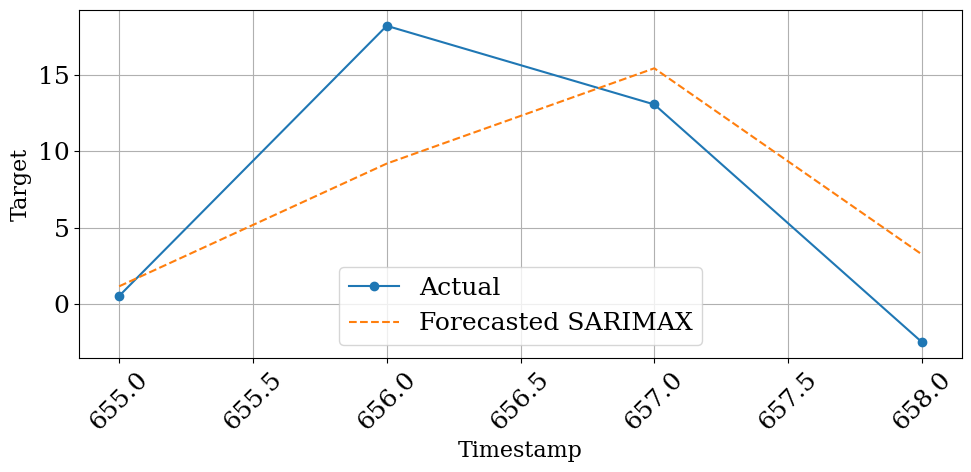

(4.4277581498368495, 1.0371521111384951)

In [204]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


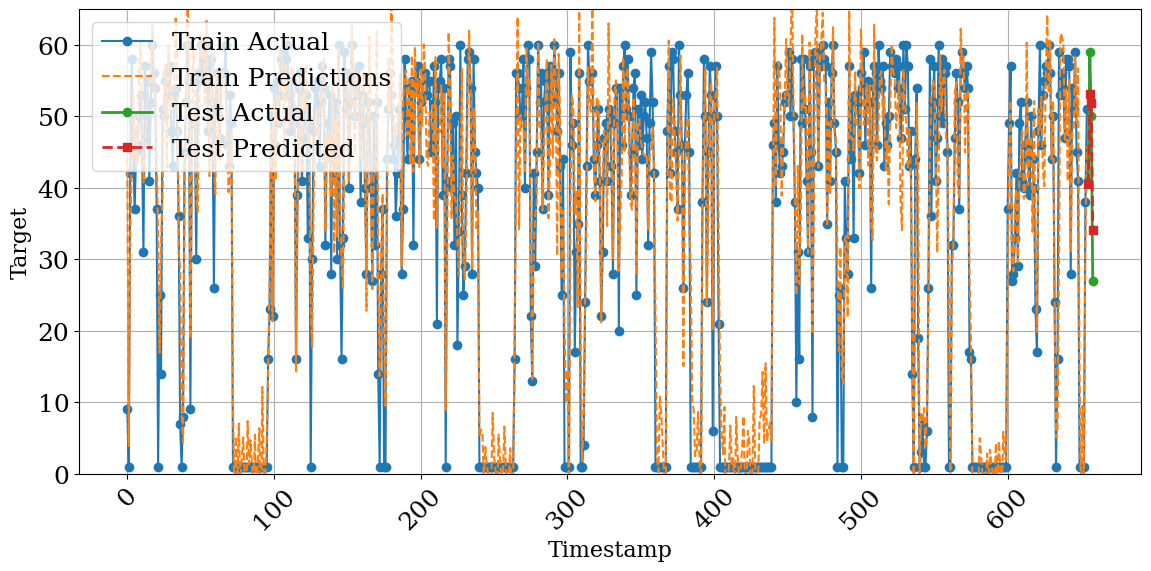

Train MAE: 5.8813
Train MAPE: 2.4672
Test MAE: 4.4278
Test MAPE: 1.0372


In [205]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

combined_train_predictions = decompose_df['total'].iloc[24:].reset_index(drop=True) + train_predictions.reset_index(drop=True)

# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, data_master_train['Operation'].iloc[24:], label='Train Actual', color='#1f77b4', marker='o')
plt.plot(train_data.index, combined_train_predictions , label='Train Predictions', color='#ff7f0e', linestyle='--')
plt.plot(test_data.index, data_master_test['Operation'], label='Test Actual ', linestyle='-',color='#2ca02c', marker='o', linewidth=2)
plt.plot(test_data.index, predicted, label='Test Predicted', marker='s', color='#d62728', linestyle='--', linewidth=2)
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(0, 65)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     41.287903
1     50.004362
2     53.031309
3     33.559815
MAE: 4.72
MAPE: 11.58%


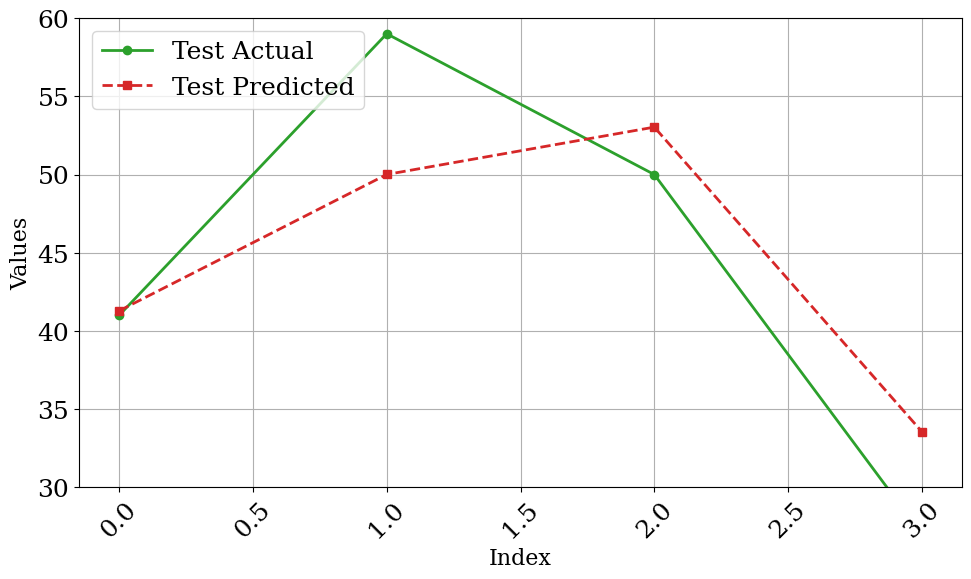

In [206]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [207]:
end_time=time.time()

In [208]:
Cost = end_time - start_time

In [209]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO FEATUREs', mae, mape,Cost)

In [210]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295
1,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,2.764303
2,Topological Dataset,0,0,0
3,SARIMA W ALL FEATUREs,19.755365,0.525458,79.955089
4,SARIMA W RFE FEATUREs,6.729181,0.199648,402.748456
5,SARIMA W RFE + PSO FEATUREs,3.019069,0.08534,10.604915
6,SARIMA W RFE + PSO BEST FEATUREs,3.019069,0.08534,11.073368
7,Topological Dataset,0,0,0
8,SARIMA W ALL FEATUREs,8.755039,0.200302,143.152084
9,SARIMA W RFE FEATUREs,11.495713,0.325241,736.31028


# MODEL 4 - 1: SARIMA W RFE+PSO BEST FEATURE SELECTION

In [211]:
start_time=time.time()

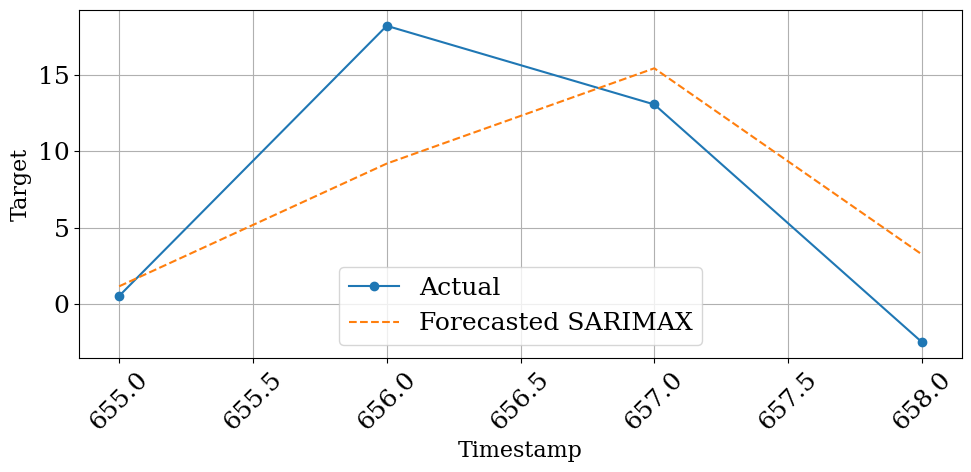

(4.4277581498368495, 1.0371521111384951)

In [212]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


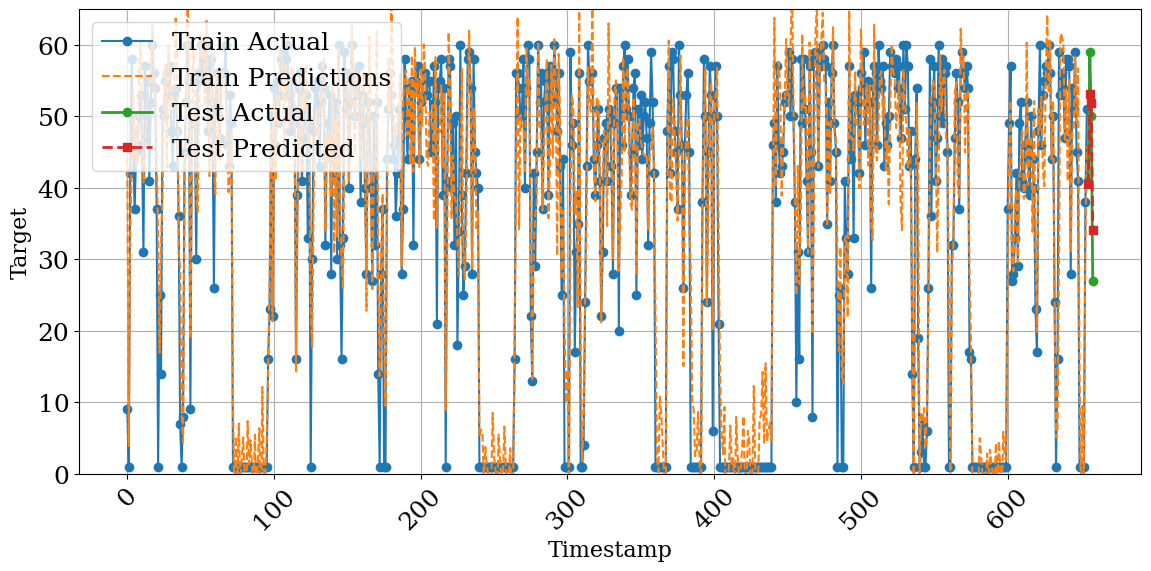

Train MAE: 5.8813
Train MAPE: 2.4672
Test MAE: 4.4278
Test MAPE: 1.0372


In [213]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(1, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

combined_train_predictions = decompose_df['total'].iloc[24:].reset_index(drop=True) + train_predictions.reset_index(drop=True)

# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, data_master_train['Operation'].iloc[24:], label='Train Actual', color='#1f77b4', marker='o')
plt.plot(train_data.index, combined_train_predictions , label='Train Predictions', color='#ff7f0e', linestyle='--')
plt.plot(test_data.index, data_master_test['Operation'], label='Test Actual ', linestyle='-',color='#2ca02c', marker='o', linewidth=2)
plt.plot(test_data.index, predicted, label='Test Predicted', marker='s', color='#d62728', linestyle='--', linewidth=2)
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(0, 65)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     41.287903
1     50.004362
2     53.031309
3     33.559815
MAE: 4.72
MAPE: 11.58%


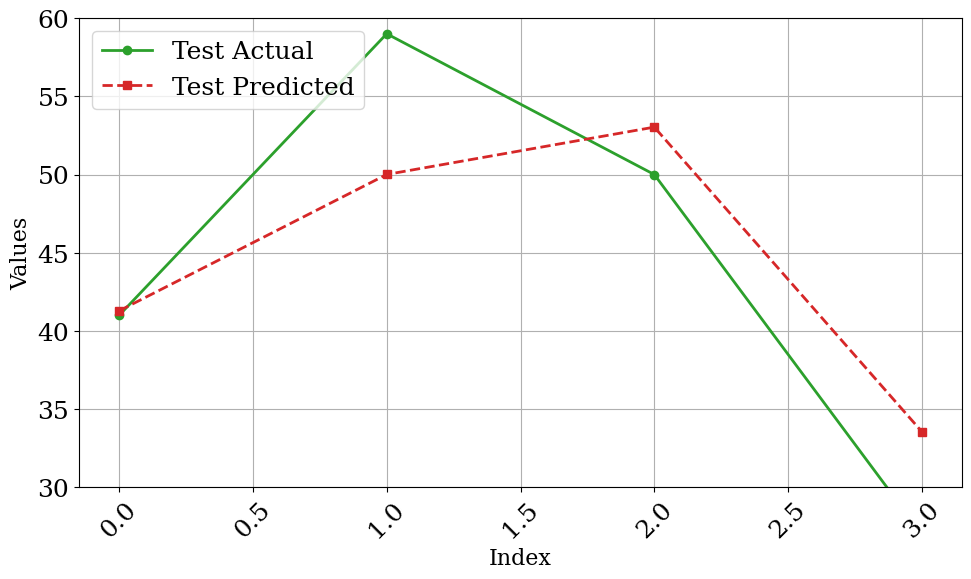

In [214]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()


In [215]:
end_time=time.time()

In [216]:
Cost = end_time - start_time

In [217]:
main_results = update_results(main_results, 'SARIMA W RFE + PSO BEST FEATUREs', mae, mape,Cost)

In [218]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295
1,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,2.764303
2,Topological Dataset,0,0,0
3,SARIMA W ALL FEATUREs,19.755365,0.525458,79.955089
4,SARIMA W RFE FEATUREs,6.729181,0.199648,402.748456
5,SARIMA W RFE + PSO FEATUREs,3.019069,0.08534,10.604915
6,SARIMA W RFE + PSO BEST FEATUREs,3.019069,0.08534,11.073368
7,Topological Dataset,0,0,0
8,SARIMA W ALL FEATUREs,8.755039,0.200302,143.152084
9,SARIMA W RFE FEATUREs,11.495713,0.325241,736.31028


In [219]:
main_results

,Model_Name,MAE,MAPE,Cost
0,BASE SARIMA WITHOUT DECOMPOSITION,14.107829,0.293031,2.295
1,SARIMA by DECOMPOSITION W NO FEATURE,3.883099,0.104131,2.764303
2,Topological Dataset,0,0,0
3,SARIMA W ALL FEATUREs,19.755365,0.525458,79.955089
4,SARIMA W RFE FEATUREs,6.729181,0.199648,402.748456
5,SARIMA W RFE + PSO FEATUREs,3.019069,0.08534,10.604915
6,SARIMA W RFE + PSO BEST FEATUREs,3.019069,0.08534,11.073368
7,Topological Dataset,0,0,0
8,SARIMA W ALL FEATUREs,8.755039,0.200302,143.152084
9,SARIMA W RFE FEATUREs,11.495713,0.325241,736.31028


In [220]:
main_results.to_excel("main_results.xlsx", index=False)